### INSTALACIÓN DE LIBRERÍAS:

In [ ]:
!pip install earthengine-api

In [ ]:
!pip install geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.6 MB/s eta 0:00:00


In [ ]:
!pip install contextily

### IMPORTACIÓN DE LIBRERÍAS:

In [ ]:
# =========================
# MANEJO DE ARCHIVOS Y SISTEMA
# =========================
import os               # Operaciones con rutas, archivos y carpetas
import re               # Expresiones regulares para buscar o limpiar texto
import math             # Funciones matemáticas básicas
import tempfile         # Creación de archivos/carpetas temporales
from pathlib import Path  # Manejo moderno de rutas

# =========================
# MANEJO DE DATOS TABULARES Y NUMÉRICOS
# =========================
import pandas as pd     # DataFrames y análisis tabular
import numpy as np      # Arreglos y cálculo numérico eficiente

# =========================
# DATOS ESPACIALES Y GEOMETRÍA
# =========================
import geopandas as gpd                     # DataFrames geográficos
import shapely                              # Operaciones geométricas
from shapely.geometry import Point, MultiPoint  # Geometrías puntuales
from shapely.geometry import shape as shp_shape # Convertir geometrías tipo geojson a shapely
import fiona                                # Lectura/escritura de archivos vectoriales geoespaciales

# =========================
# RASTERS Y TELEDETECCIÓN
# =========================
import rasterio         # Lectura y procesamiento de datos raster
from osgeo import gdal  # Herramientas raster/vector avanzadas de GDAL

# =========================
# VISUALIZACIÓN ESTÁTICA
# =========================
import matplotlib.pyplot as plt         # Gráficos en general
import matplotlib.image as mpimg        # Lectura/uso de imágenes en matplotlib
import matplotlib.patches as mpatches   # Elementos gráficos como rectángulos o leyendas
from matplotlib.patches import Patch    # Parches para leyendas personalizadas
from matplotlib.lines import Line2D     # Líneas personalizadas para leyendas
import seaborn as sns                   # Visualización estadística sobre matplotlib

# =========================
# MAPAS BASE Y VISUALIZACIÓN ESPACIAL
# =========================
import contextily as ctx    # Agregar mapas base tipo OSM/Carto a gráficos geopandas
import folium               # Mapas interactivos en navegador
from folium.plugins import TimestampedGeoJson  # Capas temporales animadas en folium

# =========================
# EARTH ENGINE Y GEEMAP
# =========================
import ee              # API de Google Earth Engine
import geemap          # Integración entre Earth Engine, folium y geopandas

# =========================
# DESCARGA DE ARCHIVOS Y WEB
# =========================
import requests        # Descarga de archivos o consultas HTTP

# **CREACIÓN DE POLÍGONOS ANUALES**

In [ ]:
ruta='/content/geometriasxcasoxminabambas.gpkg'

In [ ]:
# Listar capas involucradas
capas = fiona.listlayers(ruta)
print(capas)

['Carretera', 'Mina', 'Puente', 'Rio_Quebrada', 'Centros_Poblados']


In [ ]:
#Reporte de defensoría de las bambas
reportefechaconflicto=pd.read_csv(r'/content/ReporteFechaxConflicto_bambas.csv')
reportefechaconflicto=reportefechaconflicto[['Estado','GrupoID', 'FechaReporte']].drop_duplicates()
reportefechaconflicto=reportefechaconflicto[reportefechaconflicto.Estado=='Activo'] #Se filtran solo los conflictos activos

In [ ]:
# Diccionario de buffers en metros
buffer_rules = {
    'Carretera': 500,
    'Puente': 20,
    'Rio_Quebrada': 500,
    'Mina': 500
}

In [ ]:
minas=gpd.read_file('/content/Área en Operación Minera.geojson') #Minas de la base de datos de INGEMMET
minasexcluyentes=minas[~minas.PROYECTO.str.contains('Ferrobamba')]
#minasexcluyentes=minas[~(minas.PROYECTO.str.contains('Yanacocha')| minas.PROYECTO.str.contains('Quellaveco') | minas.PROYECTO.str.contains('Toromocho') | minas.PROYECTO.str.contains('Antamina') | minas.PROYECTO.str.contains('Antapaccay') |  minas.PROYECTO.str.contains('Animon')   | minas.PROYECTO.str.contains('Cerro Corona') |  minas.PROYECTO.str.contains('Pucamarca') | minas.PROYECTO.str.contains('Ferrobamba'))]

In [ ]:
DENSIDAD_MIN = 3000  # hab/km²

# Paso 2: Ajustar la densidad solo si el centro poblado es urbano
def ajustar_densidad_tipo(row):
    if row['AREA_17']:
        return max(row['densidad_poblacional'], DENSIDAD_MIN)
    else:
        return row['densidad_poblacional']

In [ ]:
def generar_buffers(mina_objetivo, ruta):
  gdfs_filtrados_buffer = {}

  for capa in capas:
      gdf = gpd.read_file(ruta, layer=capa)

      # Filtrar por mina si aplica
      if 'Minas_list' in gdf.columns:
          gdf = gdf[gdf['Minas_list'] == mina_objetivo]

      # Aplicar buffer si está definido
      if capa in buffer_rules:
          distancia = buffer_rules[capa]
          gdf = gdf.to_crs(epsg=32718)
          gdf['geometry'] = gdf.geometry.buffer(distancia)
          gdf = gdf.to_crs(epsg=4326)

      # Si es centros poblados, hacer el buffer circular personalizado
      elif capa == 'Centros_Poblados':
          # 1. Ajustar densidad
          gdf['densidad_ajustada'] = gdf.apply(ajustar_densidad_tipo, axis=1)
          gdf['Población Total'] = gdf['Población Total'].fillna(1)
          gdf['Area_Estimada'] = gdf['Población Total'] / gdf['densidad_ajustada']

          # 2. Pasar a proyección en metros
          gdf_proj = gdf.to_crs(epsg=32718)
          gdf_proj['Area_m2'] = gdf_proj['Area_Estimada'] * 1e6

          # 3. Calcular radios
          gdf_proj['radio_m'] = np.sqrt(gdf_proj['Area_m2'] / np.pi)

          # 4. Crear buffer circular
          gdf_proj['geometry'] = gdf_proj.buffer(gdf_proj['radio_m'])

          # 5. Regresar a WGS84
          gdf = gdf_proj.to_crs(epsg=4326)

      # Guardar resultado
      gdfs_filtrados_buffer[capa] = gdf

  return gdfs_filtrados_buffer

In [ ]:
capa_diccionario={'Carretera':'construcciones_humanas',
                   'Puente':'construcciones_humanas',
                   'Rio_Quebrada':'accidente_geografico',
                   'Mina':'mina',
                   'Centros_Poblados':'centros_poblados'}

In [ ]:
def generar_area_de_conflictos(gdfs_filtrados_buffer, ratio, años):
  total=[]
  ag_puntos={}
  ch_puntos={}
  cp_puntos={}
  mina_puntos={}

  for i in años:
    points = []
    accidentes_geograficos_points = []
    construcciones_humanas_points = []
    centros_poblados_points=[]
    mina_points=[]

    for gdframe in gdfs_filtrados_buffer:

      gdf=gdfs_filtrados_buffer[gdframe]

      if gdframe!='Mina':
        try:
          gdf=gdf.merge(reportefechaconflicto, left_on='GRUPO_ID', right_on='GrupoID', how='inner')
        except:
          gdf=gdf.merge(reportefechaconflicto, left_on='GRUPOID', right_on='GrupoID', how='inner')
        gdf['Año'] = pd.to_datetime(
                    gdf['FechaReporte'],
                    format='%d/%m/%Y',
                    errors='coerce'
                ).dt.year
        gdf=gdf[gdf.Año==i]

      for geom in gdf.geometry.dropna().unique():
          if geom.geom_type == 'Point':
              points.append(geom)
              if capa_diccionario[gdframe]=='accidente_geografico':
                  accidentes_geograficos_points.append(geom)
              elif capa_diccionario[gdframe]=='construcciones_humanas':
                  construcciones_humanas_points.append(geom)
              elif capa_diccionario[gdframe]=='centros_poblados':
                  centros_poblados_points.append(geom)
              elif capa_diccionario[gdframe]=='mina':
                  mina_points.append(geom)
              else:
                  print(f"Tipo de geometría no manejado: {geom.geom_type} en capa {gdframe}")

          elif geom.geom_type == 'MultiPoint':
              points.extend(geom.geoms)
              if capa_diccionario[gdframe]=='accidente_geografico':
                  accidentes_geograficos_points.extend(geom.geoms)
              elif capa_diccionario[gdframe]=='construcciones_humanas':
                  construcciones_humanas_points.extend(geom.geoms)
              elif capa_diccionario[gdframe]=='centros_poblados':
                  centros_poblados_points.extend(geom.geoms)
              elif capa_diccionario[gdframe]=='mina':
                  mina_points.extend(geom.geoms)
              else:
                  print(f"Tipo de geometría no manejado: {geom.geom_type} en capa {gdframe}")

          elif geom.geom_type == 'Polygon':
              points.extend([Point(x, y) for x, y in geom.exterior.coords])
              if capa_diccionario[gdframe]=='accidente_geografico':
                  accidentes_geograficos_points.extend([Point(x, y) for x, y in geom.exterior.coords])
              elif capa_diccionario[gdframe]=='construcciones_humanas':
                  construcciones_humanas_points.extend([Point(x, y) for x, y in geom.exterior.coords])
              elif capa_diccionario[gdframe]=='centros_poblados':
                  centros_poblados_points.extend([Point(x, y) for x, y in geom.exterior.coords])
              elif capa_diccionario[gdframe]=='mina':
                  mina_points.extend([Point(x, y) for x, y in geom.exterior.coords])
              else:
                  print(f"Tipo de geometría no manejado: {geom.geom_type} en capa {gdframe}")

          elif geom.geom_type == 'MultiPolygon':
              for poly in geom.geoms:
                  points.extend([Point(x, y) for x, y in poly.exterior.coords])
                  if capa_diccionario[gdframe]=='accidente_geografico':
                      accidentes_geograficos_points.extend([Point(x, y) for x, y in poly.exterior.coords])
                  elif capa_diccionario[gdframe]=='construcciones_humanas':
                      construcciones_humanas_points.extend([Point(x, y) for x, y in poly.exterior.coords])
                  elif capa_diccionario[gdframe]=='centros_poblados':
                      centros_poblados_points.extend([Point(x, y) for x, y in poly.exterior.coords])
                  elif capa_diccionario[gdframe]=='mina':
                      mina_points.extend([Point(x, y) for x, y in poly.exterior.coords])
                  else:
                      print(f"Tipo de geometría no manejado: {geom.geom_type} en capa {gdframe}")

          elif geom.geom_type == 'LineString':
              points.extend([Point(x, y) for x, y in geom.coords])
              if capa_diccionario[gdframe]=='accidente_geografico':
                  accidentes_geograficos_points.extend([Point(x, y) for x, y in geom.coords])
              elif capa_diccionario[gdframe]=='construcciones_humanas':
                  construcciones_humanas_points.extend([Point(x, y) for x, y in geom.coords])
              elif capa_diccionario[gdframe]=='centros_poblados':
                  centros_poblados_points.extend([Point(x, y) for x, y in geom.coords])
              elif capa_diccionario[gdframe]=='mina':
                  mina_points.extend([Point(x, y) for x, y in geom.coords])
              else:
                  print(f"Tipo de geometría no manejado: {geom.geom_type} en capa {gdframe}")

          elif geom.geom_type == 'MultiLineString':
              for line in geom.geoms:
                  points.extend([Point(x, y) for x, y in line.coords])
                  if capa_diccionario[gdframe]=='accidente_geografico':
                      accidentes_geograficos_points.extend([Point(x, y) for x, y in line.coords])
                  elif capa_diccionario[gdframe]=='construcciones_humanas':
                      construcciones_humanas_points.extend([Point(x, y) for x, y in line.coords])
                  elif capa_diccionario[gdframe]=='centros_poblados':
                      centros_poblados_points.extend([Point(x, y) for x, y in line.coords])
                  elif capa_diccionario[gdframe]=='mina':
                      mina_points.extend([Point(x, y) for x, y in line.coords])
                  else:
                      print(f"Tipo de geometría no manejado: {geom.geom_type} en capa {gdframe}")

    # 2. Crear MultiPoint y calcular concave hull
    multipoint = MultiPoint(points)
    hull = shapely.concave_hull(multipoint, ratio[i])  # Ajusta ratio si necesario

    # 3. Excluir minas excluyentes
    hull_filtrado = hull.difference(minasexcluyentes.geometry.union_all())

    # 4. Convertir a GeoDataFrame
    gdf_influencia = gpd.GeoDataFrame(geometry=[hull_filtrado], crs=gdf.crs)

    gdf_influencia['Año']=i
    total.append(gdf_influencia)

    ag_puntos[i]=accidentes_geograficos_points
    ch_puntos[i]=construcciones_humanas_points
    cp_puntos[i]=centros_poblados_points
    mina_puntos[i]=mina_points

  return total,ag_puntos,ch_puntos,cp_puntos,mina_puntos

In [ ]:
años=np.array([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016,2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

In [ ]:
diccionario_ratios={2007:0.6,2008:0.6,2009:0.6 ,2010:0.6 , 2011:0.5 , 2012:0.5 , 2013:0.2 , 2014:0.5 ,2015:0.5 , 2016:0.1 , 2017: 0.1,
                    2018:0.1 , 2019:0.1 , 2020:0.1 , 2021:0.1 , 2022:0.1 , 2023:0.1 , 2024:0.1}

In [ ]:
gdfs_filtrados_buffer=generar_buffers('Las Bambas', ruta)

In [ ]:
#Se generan los polígonos para cada año (también separadamente de accidentes geográficos, construcciones humanas, centros poblados, y de mina)
totalaños, ag_puntos_bambas, ch_puntos_bambas, cp_puntos_bambas, mina_puntos_bambas =generar_area_de_conflictos(gdfs_filtrados_buffer, diccionario_ratios, años)

In [ ]:
gdf_total = gpd.GeoDataFrame(pd.concat(totalaños, ignore_index=True), crs="EPSG:4326")

In [ ]:
gdf_total.to_file("/content/serie_temporal_polígonos.geojson", driver="GeoJSON")

In [ ]:
gdf_total=gpd.read_file("/content/serie_temporal_polígonos.geojson", driver="GeoJSON")

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: driver GeoJSON does not support open option DRIVER
  return ogr_read(


In [ ]:
# 1. Reproyectar a CRS en metros (UTM zona 18S (Bambas): EPSG 32718)
gdf_proj = gdf_total.to_crs(epsg=32718)

# 2. Calcular área en m²
gdf_proj["area_m2"] = gdf_proj.geometry.area

# 3. Convertir a km²
gdf_proj["area_km2"] = gdf_proj["area_m2"] / 1e6

# 4. Volver al CRS original (WGS84)
gdf_total["area_km2"] = gdf_proj["area_km2"]

In [ ]:
gdf_total

,Año,geometry,area_km2
0,2007,"POLYGON ((-72.36376 -14.05097, -72.36345 -14.0...",102.094810
1,2008,"POLYGON ((-72.36376 -14.05097, -72.36345 -14.0...",102.094810
2,2009,"POLYGON ((-72.36376 -14.05097, -72.36345 -14.0...",102.094810
3,2010,"POLYGON ((-72.36376 -14.05097, -72.36345 -14.0...",102.094810
4,2011,"POLYGON ((-72.45267 -13.94795, -72.45264 -13.9...",919.496738
5,2012,"POLYGON ((-72.45267 -13.94795, -72.45264 -13.9...",894.253404
6,2013,"POLYGON ((-72.45267 -13.94795, -72.45264 -13.9...",1085.119731
7,2014,"POLYGON ((-72.45267 -13.94795, -72.45264 -13.9...",894.253404
8,2015,"POLYGON ((-72.45267 -13.94795, -72.45264 -13.9...",919.496738
9,2016,"POLYGON ((-72.55772 -14.05795, -72.5577 -14.05...",2841.790048


## **Visualización de evolución del Mapa**

In [ ]:
# Convertir campo Año en string de fecha para animación
gdf_total["times"] = gdf_total["Año"].astype(str)

# Crear GeoJSON animado
features = []

for _, row in gdf_total.iterrows():
    año = int(row["Año"])
    if año >= 2007:  # Solo acepta años válidos
        fecha = f"{año}-07-01T12:00:00Z"
        features.append({
            "type": "Feature",
            "geometry": row["geometry"].__geo_interface__,
            "properties": {
                "time": fecha,
                "popup": f"Año: {año}"
            }
        })

geojson = {
    "type": "FeatureCollection",
    "features": features
}

# Crear mapa
centro = gdf_total.geometry.iloc[0].centroid
m = folium.Map(location=[centro.y, centro.x], zoom_start=10)

TimestampedGeoJson(
    data=geojson,
    transition_time=500,
    period="P1Y",
    duration="P1Y",
    add_last_point=True,
    auto_play=True,
    loop=True,
    date_options='YYYY'  # Mostrar solo el año en la barra de tiempo
).add_to(m)

m

## **GRÁFICOS**

### **Evolución de Mapas**

In [ ]:
def exportar_mapa_poligono_minimal(
    gdf_poligono,
    accidentes_puntos=None,
    construcciones_puntos=None,
    minas_puntos=None,
    poblados_puntos=None,
    nombre_base="mapa_minimal",
    out_dir="Poligono_anual_bambas",
    color_poligono="#cc6677",
    alpha_poligono=0.18,
    padding_factor=0.08,
    guardar_pdf=True,
    guardar_png=True,
    dpi_pdf=300,
    dpi_png=300
):
    """
    Exporta un mapa minimalista para paper:
    sin basemap, sin ejes, con polígono + puntos.

    Genera opcionalmente:
    - PDF
    - PNG
    """

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # Reproyectar polígono
    gdf_poligono_3857 = gdf_poligono.to_crs(epsg=3857).copy()
    area_total_km2 = gdf_poligono_3857.geometry.area.sum() / 1e6

    # Reproyectar puntos
    def reproyectar(lista):
        if lista and len(lista) > 0:
            lista_unica = list(set(lista))
            return gpd.GeoDataFrame(
                geometry=lista_unica, crs="EPSG:4326"
            ).to_crs(epsg=3857)
        return None

    accidentes_gdf = reproyectar(accidentes_puntos)
    construcciones_gdf = reproyectar(construcciones_puntos)
    minas_gdf = reproyectar(minas_puntos)
    poblados_gdf = reproyectar(poblados_puntos)

    # Figura
    fig, ax = plt.subplots(figsize=(6.8, 6.8))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # Polígono
    gdf_poligono_3857.plot(
        ax=ax,
        edgecolor=color_poligono,
        facecolor=color_poligono,
        alpha=alpha_poligono,
        linewidth=1.8,
        zorder=1
    )

    # Estilos de puntos
    point_styles = {
        "Geographic features": {"gdf": accidentes_gdf, "color": "#5aae61", "size": 18},
        "Built environment":   {"gdf": construcciones_gdf, "color": "#b88a1b", "size": 18},
        "Mines":               {"gdf": minas_gdf, "color": "#ca0020", "size": 24},
        "Population centers":  {"gdf": poblados_gdf, "color": "#1f3b73", "size": 20},
    }

    for label, cfg in point_styles.items():
        if cfg["gdf"] is not None and not cfg["gdf"].empty:
            cfg["gdf"].plot(
                ax=ax,
                color=cfg["color"],
                markersize=cfg["size"],
                edgecolor="white",
                linewidth=0.35,
                alpha=0.95,
                label=label,
                zorder=2
            )

    # Ajustar extensión
    xmin, ymin, xmax, ymax = gdf_poligono_3857.total_bounds
    xpad = (xmax - xmin) * padding_factor
    ypad = (ymax - ymin) * padding_factor
    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)

    # Quitar ejes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Caja de área
    ax.text(
        0.98, 0.98,
        f"Area: {area_total_km2:.2f} km$^2$",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8.5,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="lightgray",
            alpha=0.95
        ),
        zorder=3
    )

    # Leyenda
    legend = ax.legend(
        loc="lower left",
        fontsize=8,
        frameon=True,
        framealpha=0.95,
        borderpad=0.4,
        handletextpad=0.4
    )
    legend.get_frame().set_edgecolor("lightgray")
    legend.get_frame().set_linewidth(0.8)

    plt.tight_layout()

    # Guardar
    if guardar_pdf:
        ruta_pdf = out_dir / f"{nombre_base}.pdf"
        plt.savefig(ruta_pdf, dpi=dpi_pdf, bbox_inches="tight")
        print(f"✅ PDF guardado: {ruta_pdf}")

    if guardar_png:
        ruta_png = out_dir / f"{nombre_base}.png"
        plt.savefig(ruta_png, dpi=dpi_png, bbox_inches="tight")
        print(f"✅ PNG guardado: {ruta_png}")

    plt.close(fig)

In [ ]:
# =========================
# EJECUCIÓN
# =========================
for i in range(2007, 2025):
    gdf_influencia = gdf_total[gdf_total.Año == i]

    exportar_mapa_poligono_minimal(
        gdf_poligono=gdf_influencia,
        accidentes_puntos=ag_puntos_bambas.get(i, []),
        construcciones_puntos=ch_puntos_bambas.get(i, []),
        minas_puntos=mina_puntos_bambas.get(i, []),
        poblados_puntos=cp_puntos_bambas.get(i, []),
        nombre_base=f"lasbambas_{i}_minimal",
        out_dir="/content/Poligono_anual_bambas",
        guardar_pdf=True,
        guardar_png=True,
        dpi_pdf=300,
        dpi_png=300
    )

✅ PDF guardado: /content/Poligono_anual_bambas/lasbambas_2007_minimal.pdf
✅ PNG guardado: /content/Poligono_anual_bambas/lasbambas_2007_minimal.png
✅ PDF guardado: /content/Poligono_anual_bambas/lasbambas_2008_minimal.pdf
✅ PNG guardado: /content/Poligono_anual_bambas/lasbambas_2008_minimal.png
✅ PDF guardado: /content/Poligono_anual_bambas/lasbambas_2009_minimal.pdf
✅ PNG guardado: /content/Poligono_anual_bambas/lasbambas_2009_minimal.png
✅ PDF guardado: /content/Poligono_anual_bambas/lasbambas_2010_minimal.pdf
✅ PNG guardado: /content/Poligono_anual_bambas/lasbambas_2010_minimal.png
✅ PDF guardado: /content/Poligono_anual_bambas/lasbambas_2011_minimal.pdf
✅ PNG guardado: /content/Poligono_anual_bambas/lasbambas_2011_minimal.png
✅ PDF guardado: /content/Poligono_anual_bambas/lasbambas_2012_minimal.pdf
✅ PNG guardado: /content/Poligono_anual_bambas/lasbambas_2012_minimal.png
✅ PDF guardado: /content/Poligono_anual_bambas/lasbambas_2013_minimal.pdf
✅ PNG guardado: /content/Poligono_anua

### **Vinculación con cantidad de centros poblados**

In [ ]:
reportefechaconflicto.FechaReporte=pd.to_datetime(reportefechaconflicto.FechaReporte)
reportefechaconflicto.FechaReporte=reportefechaconflicto.FechaReporte.dt.year
reportefechaconflicto.drop_duplicates(inplace=True)
serie_temporal=reportefechaconflicto.groupby('FechaReporte').count()['GrupoID']
# Completar serie_temporal con años faltantes dentro de su propio rango
rango_completo = range(serie_temporal.index.min(), serie_temporal.index.max() + 1)
serie_temporal = serie_temporal.reindex(rango_completo, fill_value=0)  # usa 0 si significa "sin conflictos reportados"
bambas_temporal_activo=reportefechaconflicto.sort_values('FechaReporte')

/tmp/ipykernel_567/595497827.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  reportefechaconflicto.FechaReporte=pd.to_datetime(reportefechaconflicto.FechaReporte)


In [ ]:
gdf_total_conflictos_activos=gdf_total.merge(serie_temporal, left_on='Año', right_index=True, how='left')

In [ ]:
gdf_total_conflictos_activos

,Año,geometry,area_km2,times,Cantidad de Conflictos Activos,Cantidad de Pueblos
0,2007,"POLYGON ((-72.36376 -14.05097, -72.36345 -14.0...",102.094810,2007,1,11
1,2008,"POLYGON ((-72.36376 -14.05097, -72.36345 -14.0...",102.094810,2008,1,11
2,2009,"POLYGON ((-72.36376 -14.05097, -72.36345 -14.0...",102.094810,2009,1,11
3,2010,"POLYGON ((-72.36376 -14.05097, -72.36345 -14.0...",102.094810,2010,1,11
4,2011,"POLYGON ((-72.45267 -13.94795, -72.45264 -13.9...",919.496738,2011,1,181
5,2012,"POLYGON ((-72.45267 -13.94795, -72.45264 -13.9...",894.253404,2012,3,181
6,2013,"POLYGON ((-72.45267 -13.94795, -72.45264 -13.9...",1085.119731,2013,4,218
7,2014,"POLYGON ((-72.45267 -13.94795, -72.45264 -13.9...",894.253404,2014,3,181
8,2015,"POLYGON ((-72.45267 -13.94795, -72.45264 -13.9...",919.496738,2015,2,181
9,2016,"POLYGON ((-72.55772 -14.05795, -72.5577 -14.05...",2841.790048,2016,3,181


In [ ]:
pueblos = gpd.read_file(ruta, layer='Centros_poblados')

In [ ]:
cantidadespueblo=[]
for i in range(2007, 2025):
  grupos_activos=bambas_temporal_activo[(bambas_temporal_activo.FechaReporte==i)].GrupoID.unique()
  cantidad=pueblos[pueblos.GRUPO_ID.isin(grupos_activos)].UBIGEO.unique().shape[0]
  cantidadespueblo.append(cantidad)

In [ ]:
gdf_total_conflictos_activos['Cantidad de Pueblos']=cantidadespueblo

In [ ]:
gdf_total_conflictos_activos

,Año,geometry,area_km2,times,GrupoID,Cantidad de Pueblos
0,2007,"POLYGON ((-72.36376 -14.05097, -72.36345 -14.0...",102.094810,2007,1,11
1,2008,"POLYGON ((-72.36376 -14.05097, -72.36345 -14.0...",102.094810,2008,1,11
2,2009,"POLYGON ((-72.36376 -14.05097, -72.36345 -14.0...",102.094810,2009,1,11
3,2010,"POLYGON ((-72.36376 -14.05097, -72.36345 -14.0...",102.094810,2010,1,11
4,2011,"POLYGON ((-72.45267 -13.94795, -72.45264 -13.9...",919.496738,2011,1,181
5,2012,"POLYGON ((-72.45267 -13.94795, -72.45264 -13.9...",894.253404,2012,3,181
6,2013,"POLYGON ((-72.45267 -13.94795, -72.45264 -13.9...",1085.119731,2013,4,218
7,2014,"POLYGON ((-72.45267 -13.94795, -72.45264 -13.9...",894.253404,2014,3,181
8,2015,"POLYGON ((-72.45267 -13.94795, -72.45264 -13.9...",919.496738,2015,2,181
9,2016,"POLYGON ((-72.55772 -14.05795, -72.5577 -14.05...",2841.790048,2016,3,181


In [ ]:
gdf_total_conflictos_activos=gdf_total_conflictos_activos.rename(columns={'GrupoID':'Cantidad de Conflictos Activos'})

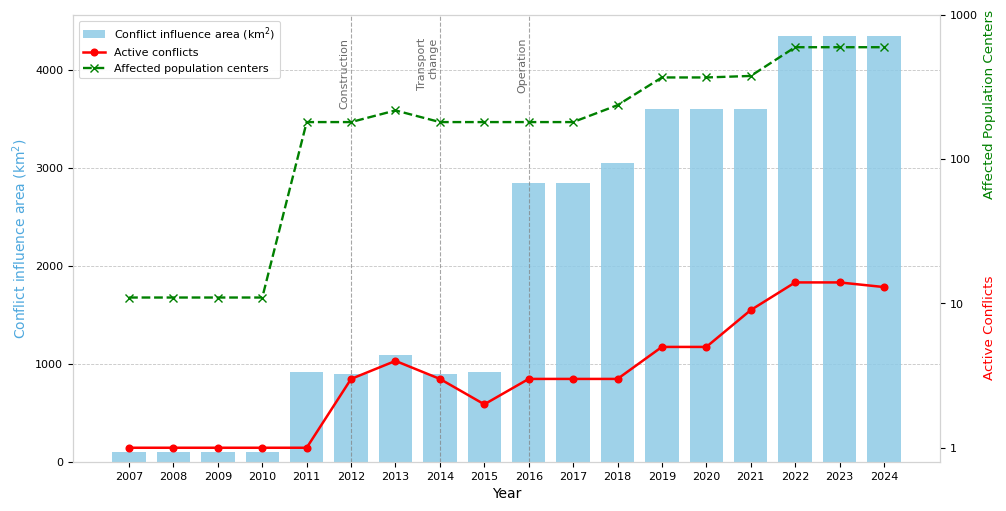

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FuncFormatter, NullLocator

# =========================
# DATOS
# =========================
df = gdf_total_conflictos_activos[
    ['Año', 'area_km2', 'Cantidad de Conflictos Activos', 'Cantidad de Pueblos']
].copy()

# =========================
# FIGURA
# =========================
fig, ax1 = plt.subplots(figsize=(10.5, 5.2))
fig.patch.set_facecolor("white")
ax1.set_facecolor("white")

# =========================
# COLORES
# =========================
bar_color = "#8ecae6"      # celeste suave
left_text_color = "#4ea8de"  # celeste un poco más intenso para el eje izquierdo
red_color = "red"
green_color = "green"

# =========================
# EJE IZQUIERDO: área de influencia
# =========================
ax1.bar(
    df['Año'],
    df['area_km2'],
    color=bar_color,
    alpha=0.85,
    width=0.75,
    edgecolor="none",
    label='Conflict influence area (km$^2$)',
    zorder=2
)

ax1.set_ylabel("Conflict influence area (km$^2$)", color=left_text_color, fontsize=10)
ax1.set_xlabel("Year", fontsize=10)
ax1.tick_params(axis='x', labelsize=8)
ax1.tick_params(axis='y', labelsize=8)   # si quieres, aquí puedes poner colors=left_text_color

# =========================
# EJE DERECHO: conflictos y pueblos afectados
# =========================
ax2 = ax1.twinx()

ax2.plot(
    df['Año'],
    df['Cantidad de Conflictos Activos'],
    color=red_color,
    marker='o',
    markersize=4.8,
    linewidth=1.8,
    linestyle='-',
    label='Active conflicts',
    zorder=4
)

ax2.plot(
    df['Año'],
    df['Cantidad de Pueblos'],
    color=green_color,
    linestyle='--',
    marker='x',
    markersize=5.5,
    linewidth=1.7,
    label='Affected population centers',
    zorder=4
)

ax2.set_yscale("log")

# Ticks del eje derecho: 1, 10, 100, 1000
major_ticks = [1, 10, 100, 1000]
ax2.yaxis.set_major_locator(FixedLocator(major_ticks))
ax2.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f"{int(y)}" if y in major_ticks else "")
)
ax2.yaxis.set_minor_locator(NullLocator())

# Límites del eje derecho
ax2.set_ylim(0.8, 1000)

# Ticks del eje derecho en negro
ax2.tick_params(axis='y', labelsize=8, colors='black')

# Quitamos ylabel del eje derecho
ax2.set_ylabel("")

# =========================
# EJE X
# =========================
ax1.set_xticks(df['Año'])
ax1.set_xticklabels(df['Año'], rotation=0)

# =========================
# HITOS
# =========================
milestones = {
    2012: "Construction",
    2014: "Transport\nchange",
    2016: "Operation"
}

y_top = ax1.get_ylim()[1]
for year, label in milestones.items():
    ax1.axvline(
        x=year,
        color='gray',
        linestyle='--',
        linewidth=0.8,
        alpha=0.7,
        zorder=3
    )
    ax1.text(
        year - 0.03,
        y_top * 0.95,
        label,
        rotation=90,
        va='top',
        ha='right',
        fontsize=8,
        color='dimgray'
    )

# =========================
# GRID
# =========================
ax1.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.45, color='gray', zorder=1)
ax1.grid(axis='x', visible=False)

# =========================
# LEYENDA COMBINADA
# =========================
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

legend = ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="lightgray",
    framealpha=0.95,
    fontsize=8
)
legend.get_frame().set_linewidth(0.8)

# =========================
# SPINES SUAVES
# =========================
for spine in ax1.spines.values():
    spine.set_color("lightgray")
    spine.set_linewidth(0.8)

for spine in ax2.spines.values():
    spine.set_color("lightgray")
    spine.set_linewidth(0.8)

# =========================
# ETIQUETAS DEL EJE DERECHO (MEJOR ALINEADAS)
# =========================
ax2.set_ylabel("")

# Un poco más de espacio a la derecha, pero no tanto
plt.tight_layout()
plt.subplots_adjust(right=0.9)

x_label = 1.05

ax2.text(x_label, 0.3, "Active Conflicts",
         transform=ax2.transAxes, rotation=90,
         va='center', ha='left', fontsize=9.7,
         color=red_color, clip_on=False)

ax2.text(x_label, 0.8, "Affected Population Centers",
         transform=ax2.transAxes, rotation=90,
         va='center', ha='left', fontsize=9.7,
         color=green_color, clip_on=False)

#ax2.text(x_label, 0.90, "(log scale)",
#         transform=ax2.transAxes, rotation=90,
#         va='center', ha='left', fontsize=8.5,
#         color='dimgray', clip_on=False)

# =========================
# EXPORTAR
# =========================
plt.savefig(
    'mining_development_python_final.pdf',
    bbox_inches='tight',
    dpi=600
)

plt.show()

# **MAPBIOMAS**

## **COBERTURA**

In [ ]:
!earthengine authenticate
ee.Initialize(project='minas-rfcaballeroc123')
mapbiomas = ee.Image('projects/mapbiomas-public/assets/peru/collection3/mapbiomas_peru_collection3_integration_v1')

E0000 00:00:1774035006.130507   39195 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774035006.136656   39195 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774035006.153501   39195 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774035006.153546   39195 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774035006.153550   39195 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774035006.153555   39195 computation_placer.cc:177] computation placer already registered. Please check linka

### **EXTRACCIÓN DATA (POR POLÍGONO REPRESENTATIVO)**

In [ ]:
years = list(range(2007, 2025))
# Extraer bandas correspondientes
bandas = [f'classification_{year}' for year in years]

# Seleccionar esas bandas
mapbiomas_bandas = mapbiomas.select(bandas)

In [ ]:
codigo_a_clase = {
    1: [1,"1. Forest formation", "Forest formation", "#1f8d49"],
    3: [1,"1.1. Forest", "Forest", "#1f8d49"],
    4: [1,"1.2. Dry forest", "Dry forest", "#7dc975"],
    5: [1,"1.3. Mangrove", "Mangrove", "#04381d"],
    6: [1,"1.4. Flooded forest", "Flooded forest", "#026975"],
    10: [2,"2. Natural non-forest formation", "Natural non-forest formation", "#d6bc74"],
    11: [2,"2.1. Swamp or flooded grassland", "Swamp or flooded grassland", "#519799"],
    12: [2,"2.2. Grassland / herbaceous vegetation", "Grassland / herbaceous vegetation", "#d6bc74"],
    29: [2,"2.3. Rocky outcrop", "Rocky outcrop", "#ffaa5f"],
    66: [2,"2.4. Shrubland", "Shrubland", "#a89358"],
    70: [2,"2.5. Coastal hills", "Coastal hills", "#be9e00"],
    13: [2,"2.6. Other non-forest formation", "Other non-forest formation", "#d89f5c"],
    14: [3,"3. Agricultural area", "Agricultural area", "#ffefc3"],
    15: [3,"3.1. Grass", "Grass", "#edde8e"],
    18: [3,"3.2. Cropland", "Cropland", "#e974ed"],
    35: [3,"3.2.1. Oil palm", "Oil palm", "#9065d0"],
    40: [3,"3.2.2. Rice", "Rice", "#c71585"],
    72: [3,"3.2.3. Other crops", "Other crops", "#910046"],
    9: [3,"3.3. Forest plantation", "Forest plantation", "#7a5900"],
    21: [3,"3.4. Agricultural mosaic", "Agricultural mosaic", "#ffefc3"],
    22: [4,"4. Other Area without vegetation", "Area without vegetation", "#d4271e"],
    23: [4,"4.1. Beach", "Beach", "#ffa07a"],
    24: [7,"4.2. Urban infrastructure", "Urban infrastructure", "#d4271e"],
    30: [8,"4.3. Mining", "Mining", "#9c0027"],
    32: [4,"4.4. Coastal salt flat", "Coastal salt flat", "#fc8114"],
    61: [4,"4.5. Salt flat", "Salt flat", "#f5d5d5"],
    68: [4,"4.6. Other natural area without vegetation", "Other natural area without vegetation", "#E97A7A"],
    25: [4,"4.7. Other area without vegetation", "Other area without vegetation", "#db4d4f"],
    26: [5,"5. Water body", "Water body", "#2532e4"],
    33: [5,"5.1. River, lake or ocean", "River, lake or ocean", "#2532e4"],
    31: [5,"5.2. Aquaculture", "Aquaculture", "#091077"],
    34: [5,"5.3. Glacier", "Glacier", "#93dfe6"],
    27: [6,"6. Not observed", "Not observed", "#ffffff"],
    1000001: ["Mine waters", "River, lake or ocean (mine only)", "#2532e4"]
}




In [ ]:
colores_por_clase = {
    valor[1]: valor[2]
    for valor in codigo_a_clase.values()
}
solominas=gpd.read_file(ruta, layer='Mina')

In [ ]:
import ee, geemap, geopandas as gpd, pandas as pd

def analisisminaestatico_macroagua(añoreferencia):
    """
    Calcula la evolución de cobertura de suelo sobre un polígono estático (año de referencia),
    separando las macroclases (nivel 1) y distinguiendo 'Water bodies' dentro y fuera de la mina.

    Parámetros
    ----------
    añoreferencia : int
        Año del polígono de referencia (área de influencia estática).

    Retorna
    -------
    df_km2 : DataFrame
        Áreas (km²) por macroclase, separando agua dentro/fuera de la mina.
    df_pix : DataFrame
        Conteo de píxeles por macroclase, separando agua dentro/fuera de la mina.
    """

    mina = solominas[solominas.Minas_list == 'Las Bambas']

    resultados_fuera_pix = {}
    resultados_dentro_pix = {}
    resultados_fuera_km2 = {}
    resultados_dentro_km2 = {}

    # --- Geometría de referencia (polígono estático) ---
    geometrias_area_influencia = geometrias[geometrias['Año'] == añoreferencia].copy()

    # Diferencia: área fuera de la mina
    geom_fuera = gpd.GeoDataFrame(
        geometry=geometrias_area_influencia.geometry.apply(
            lambda g: g.difference(mina.geometry.union_all())
        ),
        crs=geometrias_area_influencia.crs
    )

    # Convertir a geometrías EE
    geom_fuera_ee = geemap.geopandas_to_ee(geom_fuera).geometry()
    geom_dentro_ee = geemap.geopandas_to_ee(
        gpd.GeoDataFrame(geometry=[mina.geometry.union_all()], crs=mina.crs)
    ).geometry()

    # --- Lista de años a evaluar ---
    years = sorted(pd.Series(geometrias['Año']).dropna().astype(int).unique())

    for year in years:
        banda = mapbiomas.select(f'classification_{year}')
        pixel_area_km2 = ee.Image.pixelArea().divide(1e6)

        # ======================================================
        # 1️⃣ Área fuera de la mina
        # ======================================================
        hist = banda.reduceRegion(
            reducer=ee.Reducer.frequencyHistogram(),
            geometry=geom_fuera_ee,
            scale=30,
            maxPixels=1e13
        ).getInfo().get(f'classification_{year}', {})

        area_dict = (pixel_area_km2.addBands(banda)
            .reduceRegion(
                reducer=ee.Reducer.sum().group(groupField=1, groupName='class'),
                geometry=geom_fuera_ee,
                scale=30,
                maxPixels=1e13
            )
            .getInfo()
        )

        agg_fuera_pix, agg_fuera_km2 = {}, {}
        for k, v in hist.items():
            code = int(k)
            if code in codigo_a_clase:
                macro = codigo_a_clase[code][0]
                agg_fuera_pix[macro] = agg_fuera_pix.get(macro, 0) + v

        if area_dict and 'groups' in area_dict:
            for entry in area_dict['groups']:
                code = int(entry['class'])
                if code in codigo_a_clase:
                    macro = codigo_a_clase[code][0]
                    agg_fuera_km2[macro] = agg_fuera_km2.get(macro, 0) + entry['sum']

        resultados_fuera_pix[str(year)] = agg_fuera_pix
        resultados_fuera_km2[str(year)] = agg_fuera_km2

        # ======================================================
        # 2️⃣ Área dentro de la mina
        # ======================================================
        hist = banda.reduceRegion(
            reducer=ee.Reducer.frequencyHistogram(),
            geometry=geom_dentro_ee,
            scale=30,
            maxPixels=1e13
        ).getInfo().get(f'classification_{year}', {})

        area_dict = (pixel_area_km2.addBands(banda)
            .reduceRegion(
                reducer=ee.Reducer.sum().group(groupField=1, groupName='class'),
                geometry=geom_dentro_ee,
                scale=30,
                maxPixels=1e13
            )
            .getInfo()
        )

        agg_dentro_pix, agg_dentro_km2 = {}, {}
        for k, v in hist.items():
            code = int(k)
            if code in codigo_a_clase:
                macro = codigo_a_clase[code][0]
                agg_dentro_pix[macro] = agg_dentro_pix.get(macro, 0) + v

        if area_dict and 'groups' in area_dict:
            for entry in area_dict['groups']:
                code = int(entry['class'])
                if code in codigo_a_clase:
                    macro = codigo_a_clase[code][0]
                    agg_dentro_km2[macro] = agg_dentro_km2.get(macro, 0) + entry['sum']

        resultados_dentro_pix[str(year)] = agg_dentro_pix
        resultados_dentro_km2[str(year)] = agg_dentro_km2

    # ===========================================
    # 3️⃣ Construcción de DataFrames
    # ===========================================
    df_fuera_pix = pd.DataFrame(resultados_fuera_pix).T.fillna(0)
    df_dentro_pix = pd.DataFrame(resultados_dentro_pix).T.fillna(0)
    df_fuera_km2 = pd.DataFrame(resultados_fuera_km2).T.fillna(0)
    df_dentro_km2 = pd.DataFrame(resultados_dentro_km2).T.fillna(0)

    nombres_macro = {
        1: "Natural vegetation",
        2: "Natural non-forest",
        3: "Agricultural",
        4: "Other Area without vegetation",
        5: "Water bodies",
        6: "Not observed",
        7: "Urban infrastructure",
        8: "Mining"
        }

    for df in [df_fuera_pix, df_dentro_pix, df_fuera_km2, df_dentro_km2]:
        df.rename(columns=nombres_macro, inplace=True)

    # --- Fusionar totales y separar agua ---
    df_pix = df_dentro_pix.add(df_fuera_pix, fill_value=0)
    df_km2 = df_dentro_km2.add(df_fuera_km2, fill_value=0)

    if "Water bodies" in df_fuera_km2.columns:
        df_km2["Water bodies (outside mine)"] = df_fuera_km2["Water bodies"]
        df_km2["Water bodies (inside mine)"] = df_dentro_km2["Water bodies"]
        df_km2.drop(columns=["Water bodies"], inplace=True)

    if "Water bodies" in df_fuera_pix.columns:
        df_pix["Water bodies (outside mine)"] = df_fuera_pix["Water bodies"]
        df_pix["Water bodies (inside mine)"] = df_dentro_pix["Water bodies"]
        df_pix.drop(columns=["Water bodies"], inplace=True)

    df_km2.index.name = df_pix.index.name = "Year"
    df_km2.columns.name = df_pix.columns.name = "Macroclass (L1)"

    return df_km2, df_pix


In [ ]:
df_km2_2007, df_pix_2007 = analisisminaestatico_macroagua(2007)
df_km2_2011, df_pix_2011 = analisisminaestatico_macroagua(2011)
df_km2_2013, df_pix_2013 = analisisminaestatico_macroagua(2013)
df_km2_2018, df_pix_2018 = analisisminaestatico_macroagua(2018)
df_km2_2024, df_pix_2024 = analisisminaestatico_macroagua(2024)

In [ ]:
# === Renombrado fijo de columnas ===
col_map = {
    "Agricultural": "Agricultural area",
    "Mining": "Mining",
    "Natural non-forest": "Natural non-forest formation",
    "Natural vegetation": "Forest formation",
    "Other Area without vegetation": "Other area without vegetation",
    "Urban infrastructure": "Urban infrastructure",
    "Water bodies (outside mine)": "Water body (outside mine)",
    "Water bodies (inside mine)": "Water body (inside mine)"
}

# === Colores ===
color_map = {
    "Forest formation": "#1f8d49",
    "Natural non-forest formation": "#d6bc74",
    "Agricultural area": "#ffefc3",
    "Other area without vegetation": "#E97A7A",
    "Water body (outside mine)": "#2532e4",
    "Water body (inside mine)": "#4682B4",
    "Urban infrastructure": "#d4271e",
    "Mining": "#9c0027"
}

# === Orden fijo para comparabilidad temporal ===
stack_order = [
    "Forest formation",
    "Natural non-forest formation",
    "Agricultural area",
    "Other area without vegetation",
    "Water body (outside mine)",
    "Water body (inside mine)",
    "Urban infrastructure",
    "Mining"
]


def graficar_area_macroclases_journal(
    df_km2,
    año_referencia,
    ruta_salida,
    min_pct_label=12,
    xtick_step=2,
    show=False
):
    """
    Journal-style stacked bar chart for land-cover evolution within a fixed polygon.
    Uses fixed stacking order across years for better temporal comparison.

    Parameters
    ----------
    df_km2 : pd.DataFrame
        DataFrame indexed by year, with land-cover areas in km².
    año_referencia : int
        Reference year used in the output filename.
    ruta_salida : str
        Output folder.
    min_pct_label : int or float
        Minimum percentage threshold for internal labels.
    xtick_step : int
        Show one x-axis label every 'xtick_step' years.
    show : bool
        If True, display the figure after saving.
    """

    os.makedirs(ruta_salida, exist_ok=True)

    # --- Renombrar columnas ---
    df = df_km2.rename(columns=col_map).copy()

    # --- Asegurar presencia de todas las clases ---
    for c in stack_order:
        if c not in df.columns:
            df[c] = 0.0

    # --- Ordenar por año si el índice representa años ---
    try:
        df.index = df.index.astype(int)
        df = df.sort_index()
    except Exception:
        pass

    years = df.index.astype(int).to_numpy()
    x = np.arange(len(df))

    # --- Figura ---
    fig, ax = plt.subplots(figsize=(6.8, 4.3))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # --- Barras apiladas con orden fijo ---
    bottom = np.zeros(len(df))

    for c in stack_order:
        vals = df[c].fillna(0).to_numpy()

        ax.bar(
            x,
            vals,
            bottom=bottom,
            width=0.74,
            color=color_map.get(c, "#999999"),
            edgecolor="white",
            linewidth=0.3,
            label=c,
            zorder=3
        )

        # Etiquetas internas solo si el segmento es suficientemente grande
        totals = df[stack_order].sum(axis=1).replace(0, np.nan).to_numpy()
        pcts = np.divide(vals, totals) * 100

        for i in range(len(vals)):
            if np.isfinite(pcts[i]) and pcts[i] >= min_pct_label and vals[i] > 0:
                ax.text(
                    x[i],
                    bottom[i] + vals[i] / 2,
                    f"{pcts[i]:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=6.5,
                    color="black"
                )

        bottom += vals

    # --- Hitos alineados con el paper ---
    milestones = {
        2012: "Construction",
        2014: "Transport\nchange",
        2016: "Operation"
    }

    ax.relim()
    ax.autoscale_view()
    y_top = ax.get_ylim()[1]

    for yr, label in milestones.items():
        if yr in years:
            xpos = np.where(years == yr)[0][0]
            ax.axvline(
                x=xpos,
                color="gray",
                linestyle="--",
                linewidth=0.8,
                alpha=0.75,
                zorder=2
            )
            ax.text(
                xpos + 0.05,
                y_top * 0.96,
                label,
                rotation=90,
                va="top",
                ha="left",
                fontsize=7.5,
                color="dimgray"
            )

    # --- Eje X ---
    shown_idx = list(range(0, len(years), xtick_step))
    if shown_idx[-1] != len(years) - 1:
        shown_idx.append(len(years) - 1)

    ax.set_xticks(shown_idx)
    ax.set_xticklabels(years[shown_idx], fontsize=8)
    ax.set_xlabel("Year", fontsize=9)

    # --- Eje Y ---
    ax.set_ylabel("Area (km$^2$)", fontsize=9)
    ax.tick_params(axis="y", labelsize=8)

    # --- Grid suave ---
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.45, color="gray", zorder=1)
    ax.grid(axis="x", visible=False)

    # --- Bordes limpios ---
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("lightgray")
    ax.spines["bottom"].set_color("lightgray")

    # --- Leyenda compacta ---
    handles = [Patch(facecolor=color_map[c], label=c, edgecolor="none") for c in stack_order]

    legend = ax.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.20),
        ncol=3,
        frameon=True,
        framealpha=0.95,
        facecolor="white",
        edgecolor="lightgray",
        fontsize=8,
        title="Land-cover classes",
        title_fontsize=9,
        columnspacing=1.1,
        handletextpad=0.5
    )
    legend.get_frame().set_linewidth(0.8)

    plt.tight_layout()
    out_path = os.path.join(ruta_salida, f"stacked_area_macroclass_{año_referencia}.pdf")
    plt.savefig(out_path, dpi=600, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    print(f"✅ Guardado: {out_path}")

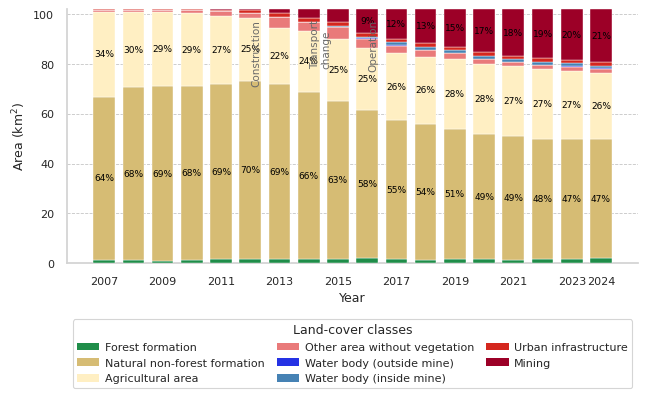

✅ Guardado: Land_cover/stacked_area_macroclass_2007.pdf


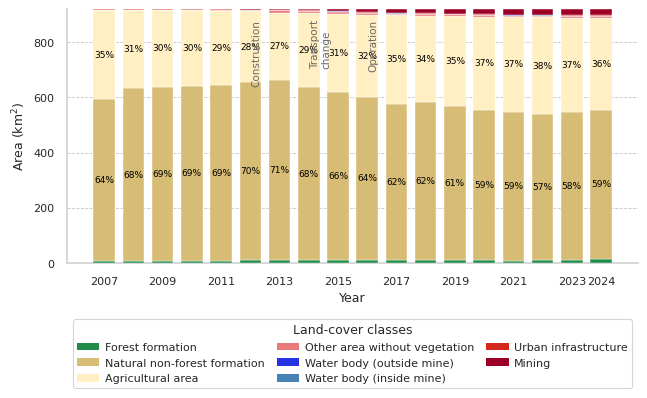

✅ Guardado: Land_cover/stacked_area_macroclass_2011.pdf


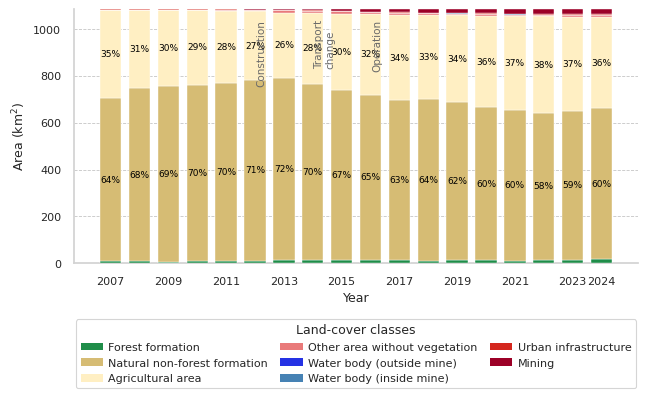

✅ Guardado: Land_cover/stacked_area_macroclass_2013.pdf


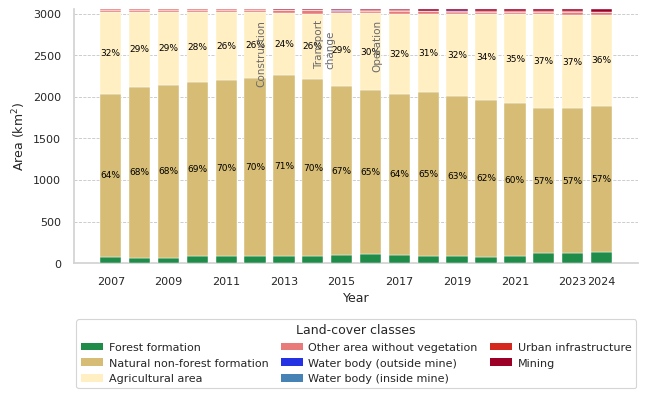

✅ Guardado: Land_cover/stacked_area_macroclass_2018.pdf


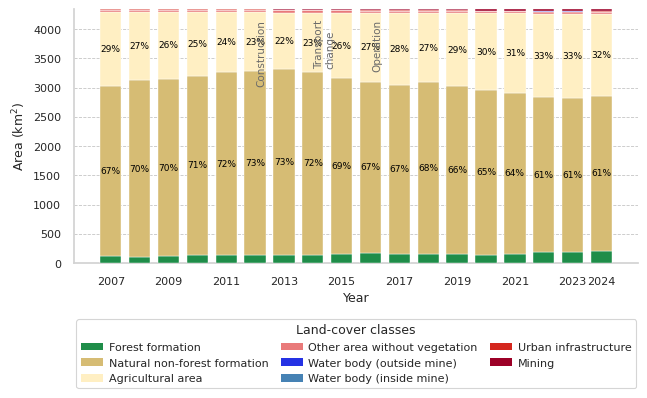

✅ Guardado: Land_cover/stacked_area_macroclass_2024.pdf


In [ ]:
ruta_graficos = 'Land_cover/'

graficar_area_macroclases_journal(df_km2_2007, 2007, ruta_graficos, min_pct_label=8, show=True)
graficar_area_macroclases_journal(df_km2_2011, 2011, ruta_graficos, min_pct_label=8, show=True)
graficar_area_macroclases_journal(df_km2_2013, 2013, ruta_graficos, min_pct_label=8, show=True)
graficar_area_macroclases_journal(df_km2_2018, 2018, ruta_graficos, min_pct_label=8, show=True)
graficar_area_macroclases_journal(df_km2_2024, 2024, ruta_graficos, min_pct_label=8, show=True)

### GRÁFICO: MAPA POR PERIODO

In [ ]:
codigo_a_clase = {
    1: [1,"1. Forest formation", "Forest formation", "#1f8d49"],
    3: [1,"1.1. Forest", "Forest", "#1f8d49"],
    4: [1,"1.2. Dry forest", "Dry forest", "#7dc975"],
    5: [1,"1.3. Mangrove", "Mangrove", "#04381d"],
    6: [1,"1.4. Flooded forest", "Flooded forest", "#026975"],
    10: [2,"2. Natural non-forest formation", "Natural non-forest formation", "#d6bc74"],
    11: [2,"2.1. Swamp or flooded grassland", "Swamp or flooded grassland", "#519799"],
    12: [2,"2.2. Grassland / herbaceous vegetation", "Grassland / herbaceous vegetation", "#d6bc74"],
    29: [2,"2.3. Rocky outcrop", "Rocky outcrop", "#ffaa5f"],
    66: [2,"2.4. Shrubland", "Shrubland", "#a89358"],
    70: [2,"2.5. Coastal hills", "Coastal hills", "#be9e00"],
    13: [2,"2.6. Other non-forest formation", "Other non-forest formation", "#d89f5c"],
    14: [3,"3. Agricultural area", "Agricultural area", "#ffefc3"],
    15: [3,"3.1. Grass", "Grass", "#edde8e"],
    18: [3,"3.2. Cropland", "Cropland", "#e974ed"],
    35: [3,"3.2.1. Oil palm", "Oil palm", "#9065d0"],
    40: [3,"3.2.2. Rice", "Rice", "#c71585"],
    72: [3,"3.2.3. Other crops", "Other crops", "#910046"],
    9: [3,"3.3. Forest plantation", "Forest plantation", "#7a5900"],
    21: [3,"3.4. Agricultural mosaic", "Agricultural mosaic", "#ffefc3"],
    22: [4,"4. Other Area without vegetation", "Area without vegetation", "#d4271e"],
    23: [4,"4.1. Beach", "Beach", "#ffa07a"],
    32: [4,"4.4. Coastal salt flat", "Coastal salt flat", "#fc8114"],
    61: [4,"4.5. Salt flat", "Salt flat", "#f5d5d5"],
    68: [4,"4.6. Other natural area without vegetation", "Other natural area without vegetation", "#E97A7A"],
    25: [4,"4.7. Other area without vegetation", "Other area without vegetation", "#db4d4f"],
    26: [5,"5. Water body", "Water body", "#2532e4"],
    33: [5,"5.1. River, lake or ocean", "River, lake or ocean", "#2532e4"],
    31: [5,"5.2. Aquaculture", "Aquaculture", "#091077"],
    34: [5,"5.3. Glacier", "Glacier", "#93dfe6"],
    27: [6,"6. Not observed", "Not observed", "#ffffff"],
    24: [7,"4.2. Urban infrastructure", "Urban infrastructure", "#d4271e"],
    30: [8,"4.3. Mining", "Mining", "#9c0027"],
    }

In [ ]:
class_codes  = sorted(int(k) for k in codigo_a_clase.keys())

In [ ]:
# --- Nombres oficiales MapBiomas ---
macroclases = {
    1: "Forest formation",
    2: "Natural non-forest formation",
    3: "Agricultural area",
    4: "Other area without vegetation",
    5: "Water body",
    6: "Not observed",
    7: "Urban infrastructure",
    8: "Mining"
}

# --- Colores oficiales MapBiomas ---
colores_macro = {
    1: "#1f8d49",   # Forest formation
    2: "#d6bc74",   # Natural non-forest formation
    3: "#ffefc3",   # Agricultural area
    4: "#E97A7A",   # Area without vegetation
    5: "#2532e4",   # Water body (outside mine)
    6: "#ffffff",   # Not observed
    7: "#d4271e",  ## Infraestructura urbana
    8: "#9c0027"   #mineria

}

In [ ]:
class_codes  = sorted(int(k) for k in codigo_a_clase.keys())

In [ ]:
# =========================
# CONFIGURACIÓN GENERAL
# =========================
ALPHA_OVER = 0.92
THUMB_DIM  = 1600
OUT_DIR    = Path("Land_cover_clases_journal")
OUT_DIR.mkdir(parents=True, exist_ok=True)

class_codes  = sorted(macroclases.keys())
class_names  = {k: macroclases[k] for k in class_codes}
class_colors = [colores_macro[k] for k in class_codes]
code2idx     = {c: i for i, c in enumerate(class_codes)}

# Orden preferido en la leyenda
legend_order = [
    1,  # Forest formation
    2,  # Natural non-forest formation
    3,  # Agricultural area
    4,  # Other area without vegetation
    5,  # Water body
    7,  # Urban infrastructure
    8   # Mining
]
legend_order = [c for c in legend_order if c in class_codes]


def make_vis_image(img, mask_not_observed=True):
    """
    Remapea códigos originales MapBiomas a índices consecutivos (0..K-1)
    según las macroclases definidas en codigo_a_clase.

    Si mask_not_observed=True, oculta los píxeles clasificados como
    'Not observed' (macroclase 6).
    """
    from_list, to_list_raw = [], []

    for k, v in codigo_a_clase.items():
        try:
            macro = int(v[0])
            from_list.append(int(k))
            to_list_raw.append(macro)
        except (ValueError, TypeError):
            continue

    to_list = [code2idx[macro] for macro in to_list_raw if macro in code2idx]

    minlen = min(len(from_list), len(to_list))
    from_list = from_list[:minlen]
    to_list   = to_list[:minlen]

    img_remap = img.remap(from_list, to_list).rename("idx")

    # Ocultar "Not observed"
    if mask_not_observed and 6 in code2idx:
        idx_not_observed = code2idx[6]
        img_remap = img_remap.updateMask(img_remap.neq(idx_not_observed))

    vis = img_remap.visualize(
        min=0,
        max=len(class_codes) - 1,
        palette=class_colors
    )
    return vis


def present_macroclasses(img, ee_geom, bandname, scale=30):
    """
    Devuelve solo las macroclases realmente presentes dentro del AOI,
    excluyendo 'Not observed'.
    """
    hist = img.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=ee_geom,
        scale=scale,
        maxPixels=1e13,
        bestEffort=True
    ).get(bandname)

    hist_info = ee.Dictionary(hist).getInfo()
    if hist_info is None:
        return []

    macro_presentes = set()
    for k in hist_info.keys():
        try:
            original_code = int(k)
            if original_code in codigo_a_clase:
                macro_id = int(codigo_a_clase[original_code][0])
                if macro_id in class_codes:
                    macro_presentes.add(macro_id)
        except Exception:
            continue

    # excluir Not observed
    macro_presentes.discard(6)

    ordered = [c for c in legend_order if c in macro_presentes]
    extras  = [c for c in class_codes if c in macro_presentes and c not in ordered and c != 6]
    return ordered + extras


def exportar_panel_b_journal(
    year,
    geometrias,
    nombre_salida,
    usar_basemap=True,
    mostrar_leyenda=True,
    mostrar_ejes=False
):
    g_ai = geometrias[geometrias["Año"].astype(int) == int(year)].copy()
    if g_ai.empty:
        print(f"[{year}] sin geometría; se omite.")
        return

    # AOI en 3857
    aoi_3857 = g_ai.to_crs(3857)
    minx, miny, maxx, maxy = aoi_3857.total_bounds

    xpad = (maxx - minx) * 0.04
    ypad = (maxy - miny) * 0.04

    # AOI para EE
    ee_ai = geemap.geopandas_to_ee(g_ai.to_crs(4326)[["geometry"]]).geometry()

    # Imagen MapBiomas
    band = f"classification_{year}"
    img_year = (
        ee.Image("projects/mapbiomas-public/assets/peru/collection3/mapbiomas_peru_collection3_integration_v1")
        .select(band)
        .rename(band)
    )

    # Raster visual
    img_rgb = make_vis_image(img_year, mask_not_observed=True).clip(ee_ai)

    # Descargar thumbnail
    url = img_rgb.getThumbURL({
        "region": ee_ai,
        "dimensions": THUMB_DIM,
        "format": "png",
        "crs": "EPSG:3857"
    })

    tmp_png = OUT_DIR / f"tmp_bambas_{year}_rgb_3857.png"
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with open(tmp_png, "wb") as f:
            for chunk in r.iter_content(8192):
                f.write(chunk)

    img_arr = mpimg.imread(tmp_png)

    # Clases presentes
    pres = present_macroclasses(img_year, ee_ai, band)

    fig, ax = plt.subplots(figsize=(6.8, 6.8))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    if usar_basemap:
        try:
            ctx.add_basemap(
                ax,
                source=ctx.providers.CartoDB.PositronNoLabels,
                crs="EPSG:3857",
                attribution=False,
                zorder=0
            )
        except Exception:
            ctx.add_basemap(
                ax,
                source=ctx.providers.CartoDB.Positron,
                crs="EPSG:3857",
                attribution=False,
                zorder=0
            )

    ax.imshow(
        img_arr,
        extent=(minx, maxx, miny, maxy),
        origin="upper",
        alpha=ALPHA_OVER,
        zorder=2
    )

    aoi_3857.boundary.plot(
        ax=ax,
        color="#8f8f8f",
        linewidth=0.8,
        zorder=3
    )

    ax.set_xlim(minx - xpad, maxx + xpad)
    ax.set_ylim(miny - ypad, maxy + ypad)

    if mostrar_ejes:
        ax.tick_params(axis="both", labelsize=8)
        ax.set_xlabel("Longitude", fontsize=9)
        ax.set_ylabel("Latitude", fontsize=9)
        for spine in ax.spines.values():
            spine.set_color("lightgray")
            spine.set_linewidth(0.8)
    else:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        for spine in ax.spines.values():
            spine.set_visible(False)

    if mostrar_leyenda and pres:
        handles = [
            mpatches.Patch(
                facecolor=class_colors[code2idx[c]],
                edgecolor="none",
                label=class_names[c]
            )
            for c in pres if c in code2idx and c != 6
        ]

        ncols = 2 if len(handles) <= 4 else 3

        legend = ax.legend(
            handles=handles,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.03),
            frameon=True,
            ncol=ncols,
            fontsize=8,
            title="Land-cover classes",
            title_fontsize=9,
            framealpha=0.95,
            borderpad=0.4,
            handletextpad=0.5,
            columnspacing=1.1,
            facecolor="white",
            edgecolor="lightgray"
        )
        legend.get_frame().set_linewidth(0.8)

    plt.tight_layout()
    plt.savefig(nombre_salida, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print(f"[{year}] guardado: {nombre_salida}")



In [ ]:
# =========================
# EJECUCIÓN
# =========================
for year in [2007, 2011, 2013, 2018, 2024]:
    out_pdf = OUT_DIR / f"bambas_{year}_OSM_journal.pdf"
    exportar_panel_b_journal(
        year=year,
        geometrias=geometrias,
        nombre_salida=out_pdf,
        usar_basemap=True,
        mostrar_leyenda=True,
        mostrar_ejes=False
    )

/usr/local/lib/python3.12/dist-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


[2007] guardado: Land_cover_clases_journal/bambas_2007_OSM_journal.pdf


/usr/local/lib/python3.12/dist-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


[2011] guardado: Land_cover_clases_journal/bambas_2011_OSM_journal.pdf


/usr/local/lib/python3.12/dist-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


[2013] guardado: Land_cover_clases_journal/bambas_2013_OSM_journal.pdf


/usr/local/lib/python3.12/dist-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


[2018] guardado: Land_cover_clases_journal/bambas_2018_OSM_journal.pdf


/usr/local/lib/python3.12/dist-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


[2024] guardado: Land_cover_clases_journal/bambas_2024_OSM_journal.pdf


## **TRANSICIONES**

In [ ]:
mapbiomas = ee.Image('projects/mapbiomas-public/assets/peru/collection3/mapbiomas_peru_collection3_transitions_v1')

In [ ]:
transiciones=pd.DataFrame(mapbiomas.bandNames().getInfo(), columns=['Transiciones'])

In [ ]:
# Extraer los años usando regex
transiciones[["anio1", "anio2"]] = transiciones["Transiciones"].str.extract(r"(\d{4})_(\d{4})").astype(int)

# Calcular el tiempo de transición
transiciones["Tiempo de transicion"] = transiciones["anio2"] - transiciones["anio1"]


In [ ]:
anio_analisis=list(range(2007,2025))

In [ ]:
transiciones.anio1=transiciones.anio1.astype(int)
transiciones.anio2=transiciones.anio2.astype(int)
transiciones_anios=transiciones[transiciones.anio1.isin(anio_analisis)].reset_index(drop=True)
transiciones_anios=transiciones_anios.iloc[:19,]

In [ ]:
transiciones_anios

,Transiciones,anio1,anio2,Tiempo de transicion
0,transitions_2007_2008,2007,2008,1
1,transitions_2008_2009,2008,2009,1
2,transitions_2009_2010,2009,2010,1
3,transitions_2010_2011,2010,2011,1
4,transitions_2011_2012,2011,2012,1
5,transitions_2012_2013,2012,2013,1
6,transitions_2013_2014,2013,2014,1
7,transitions_2014_2015,2014,2015,1
8,transitions_2015_2016,2015,2016,1
9,transitions_2016_2017,2016,2017,1


In [ ]:
codigo_a_clase = {
    1: [1,"1. Forest formation", "Forest formation", "#1f8d49"],
    3: [1,"1.1. Forest", "Forest", "#1f8d49"],
    4: [1,"1.2. Dry forest", "Dry forest", "#7dc975"],
    5: [1,"1.3. Mangrove", "Mangrove", "#04381d"],
    6: [1,"1.4. Flooded forest", "Flooded forest", "#026975"],
    10: [2,"2. Natural non-forest formation", "Natural non-forest formation", "#d6bc74"],
    11: [2,"2.1. Swamp or flooded grassland", "Swamp or flooded grassland", "#519799"],
    12: [2,"2.2. Grassland / herbaceous vegetation", "Grassland / herbaceous vegetation", "#d6bc74"],
    29: [2,"2.3. Rocky outcrop", "Rocky outcrop", "#ffaa5f"],
    66: [2,"2.4. Shrubland", "Shrubland", "#a89358"],
    70: [2,"2.5. Coastal hills", "Coastal hills", "#be9e00"],
    13: [2,"2.6. Other non-forest formation", "Other non-forest formation", "#d89f5c"],
    14: [3,"3. Agricultural area", "Agricultural area", "#ffefc3"],
    15: [3,"3.1. Grass", "Grass", "#edde8e"],
    18: [3,"3.2. Cropland", "Cropland", "#e974ed"],
    35: [3,"3.2.1. Oil palm", "Oil palm", "#9065d0"],
    40: [3,"3.2.2. Rice", "Rice", "#c71585"],
    72: [3,"3.2.3. Other crops", "Other crops", "#910046"],
    9: [3,"3.3. Forest plantation", "Forest plantation", "#7a5900"],
    21: [3,"3.4. Agricultural mosaic", "Agricultural mosaic", "#ffefc3"],
    22: [4,"4. Area without vegetation", "Area without vegetation", "#d4271e"],
    23: [4,"4.1. Beach", "Beach", "#ffa07a"],
    24: [4,"4.2. Urban infrastructure", "Urban infrastructure", "#d4271e"],
    30: [4,"4.3. Mining", "Mining", "#9c0027"],
    32: [4,"4.4. Coastal salt flat", "Coastal salt flat", "#fc8114"],
    61: [4,"4.5. Salt flat", "Salt flat", "#f5d5d5"],
    68: [4,"4.6. Other natural area without vegetation", "Other natural area without vegetation", "#E97A7A"],
    25: [4,"4.7. Other area without vegetation", "Other area without vegetation", "#db4d4f"],
    26: [5,"5. Water body", "Water body", "#2532e4"],
    33: [5,"5.1. River, lake or ocean", "River, lake or ocean", "#2532e4"],
    31: [5,"5.2. Aquaculture", "Aquaculture", "#091077"],
    34: [5,"5.3. Glacier", "Glacier", "#93dfe6"],
    27: [6,"6. Not observed", "Not observed", "#ffffff"],
    1000001: ["Mine waters", "River, lake or ocean (mine only)", "#2532e4"]
}

In [ ]:
geometrias=gdf_total.copy()

In [ ]:
BUCKET_COLOR = {
    'Reduction of water': '#ffa500',   # Transitions which reduce water surface
    'Increment of water': '#4169e1',  # Transitions which add water surface
    'Natural→Anthropic': '#ff0000',       # Natural -> Antropico
    'Anthropic→Natural': '#06ff00',       # Antropico -> Natural
    'Same macroclass/no change': '#818181'           # Sin transición relevante / no observado / misma macroclase
}


In [ ]:
def analisisminaestatico_transiciones_band_simple(nombre_mina='Las Bambas'):
    """
    Calcula transiciones MapBiomas entre años consecutivos y devuelve tres DataFrames:
    - df_pixeles: conteo de píxeles por bucket (transición)
    - df_km2: áreas equivalentes en km²
    - df_norm: proporciones de cada bucket respecto al total del periodo
    """
    # --- Años disponibles en geometrías ---
    years_geo = sorted(pd.Series(geometrias['Año']).dropna().astype(int).unique())
    years = years_geo[:-1]  # y -> y+1

    # --- Mapeo nivel 1 ---
    L1 = {k: v[0] for k, v in codigo_a_clase.items()}  # ej. 3->1, 15->3, 26->5, 33->6

    def grupo_macro(l1):
        if l1 in (1, 2): return 'NAT'
        if l1 in (3, 4): return 'ANT'
        if l1 == 5: return 'WAT'
        return 'NOOBS'

    def bucket(o, d):
        lo, ld = L1.get(o), L1.get(d)
        if lo == 5 and ld != 5: return 'Reduction of water'
        if lo != 5 and ld == 5: return 'Increment of water'
        if grupo_macro(lo) == 'NAT' and grupo_macro(ld) == 'ANT': return 'Natural→Anthropic'
        if grupo_macro(lo) == 'ANT' and grupo_macro(ld) == 'NAT': return 'Anthropic→Natural'
        return 'Same macroclass/no change'

    resultados_pix = {}
    resultados_km2 = {}

    for y in years:
        # --- Geometría ---
        gdf_geo = geometrias[geometrias['Año'] == y].copy()
        if gdf_geo.empty:
            continue
        geom_ee = geemap.geopandas_to_ee(gdf_geo).geometry()

        # --- Banda de transición ---
        banda_name = f"transitions_{y}_{y+1}"
        band_names = set(mapbiomas.bandNames().getInfo())
        if banda_name not in band_names:
            continue

        trans = mapbiomas.select(banda_name).rename('t').toInt()

        # ======================================================
        # BLOQUE 1: histograma (conteo de píxeles)
        # ======================================================
        hist = (trans.reduceRegion(
                    reducer=ee.Reducer.frequencyHistogram(),
                    geometry=geom_ee,
                    scale=30,
                    maxPixels=1e13
                ).getInfo().get('t', {}))

        agg_pix = {'Reduction of water':0, 'Increment of water':0,
                   'Natural→Anthropic':0, 'Anthropic→Natural':0,
                   'Same macroclass/no change':0}

        for k, v in hist.items():
            code = int(k)
            o, d = code // 100, code % 100
            agg_pix[bucket(o, d)] += float(v)

        resultados_pix[f'{y}→{y+1}'] = agg_pix


        # ======================================================
        # BLOQUE 2: cálculo de áreas en km² usando pixelArea()
        # ======================================================
        pixel_area_km2 = ee.Image.pixelArea().divide(1e6)

        # Invertimos el orden: primero área (para sumar), luego transición (para agrupar)
        area_dict = (
            pixel_area_km2.addBands(trans)
            .reduceRegion(
                reducer=ee.Reducer.sum().group(
                    groupField=1,          # agrupamos por la banda 1 (transición)
                    groupName='transition' # campo de salida
                ),
                geometry=geom_ee,
                scale=30,
                maxPixels=1e13
            )
            .getInfo()
        )

        agg_km2 = {
            'Reduction of water': 0,
            'Increment of water': 0,
            'Natural→Anthropic': 0,
            'Anthropic→Natural': 0,
            'Same macroclass/no change': 0
        }

        if area_dict and 'groups' in area_dict:
            for entry in area_dict['groups']:
                code = int(entry['transition'])
                area_val = entry['sum']  # área en km²
                o, d = code // 100, code % 100
                agg_km2[bucket(o, d)] += area_val

        resultados_km2[f'{y}→{y+1}'] = agg_km2


    # --- DataFrames finales ---
    df_pix = pd.DataFrame(resultados_pix).T.fillna(0)
    df_km2 = pd.DataFrame(resultados_km2).T.fillna(0)

    if df_pix.empty:
        return df_pix, df_km2, df_km2  # nada que graficar

    # --- Normalización (proporciones) ---
    df_norm = df_km2.div(df_km2.sum(axis=1), axis=0)
    df_norm.index.name   = 'Periodo'
    df_norm.columns.name = 'Bucket'

    return df_pix, df_km2, df_norm

In [ ]:
lasbambasentero, lasbambaskm2 ,lasbambasnormalizado = analisisminaestatico_transiciones_band_simple()

In [ ]:
lasbambaskm2

Bucket,Reduction of water,Increment of water,Natural→Anthropic,Anthropic→Natural,Same macroclass/no change
Periodo,,,,,
2007→2008,0.000000,0.000000,0.854792,4.673462,96.430054
2008→2009,0.000868,0.001736,0.802029,1.156266,99.997409
2009→2010,0.000868,0.002604,1.660047,1.574629,98.720161
2010→2011,0.002604,0.000868,1.723192,2.719998,97.511647
2011→2012,0.006074,0.010409,10.264152,21.702907,886.309466
2012→2013,0.003469,0.019956,8.964399,17.353008,866.734506
2013→2014,0.006065,0.090236,37.400737,11.507705,1034.578068
2014→2015,0.006074,0.373140,25.428588,6.750823,860.516715
2015→2016,0.022560,0.386154,24.738802,6.233860,886.911630


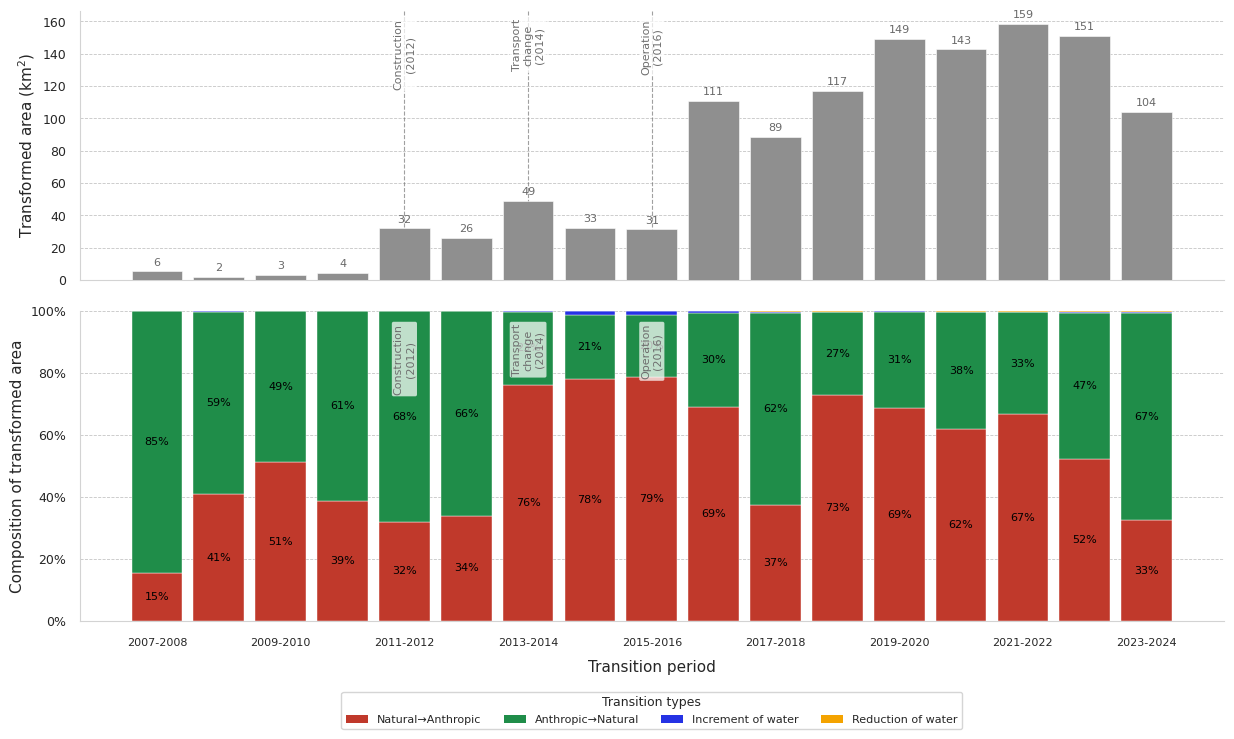

In [ ]:
def plot_transition_dynamics_two_panel(
    df_input: pd.DataFrame,
    outfile: str | None = "transition_dynamics_two_panel.pdf",
    colors_by_class: dict | None = None,
    year_construction: int | None = None,
    year_operation: int | None = None,
    year_transport_change: int | None = None,
    min_pct_label: float = 8.0,
    xtick_every: int = 2,
    xtick_style: str = "dash"   # "dash", "arrow", "original"
):
    """
    Two-panel figure for yearly land-cover transition dynamics.

    Panel A: total transformed area per transition period (km²)
    Panel B: composition of transformed area (100% stacked), excluding no-change
    """

    df = df_input.copy()

    # --- Detect Year/index ---
    if "Year" in df.columns:
        df = df.set_index("Year")

    idx_str = df.index.astype(str)
    start_years = []
    for s in idx_str:
        m = re.search(r"(\d{4})", s)
        start_years.append(int(m.group(1)) if m else None)

    # Sort by start year
    order = np.argsort([y if y is not None else 9999 for y in start_years])
    df = df.iloc[order]
    idx_str = df.index.astype(str)
    start_years = [start_years[i] for i in order]

    x = np.arange(len(df))
    x_labels_original = idx_str.tolist()
    start_year_to_pos = {y: i for i, y in enumerate(start_years) if y is not None}

    # --- Build cleaner x labels ---
    def make_period_label(i, y):
        if xtick_style == "original":
            return x_labels_original[i]
        if y is None:
            return x_labels_original[i]
        if xtick_style == "arrow":
            return f"{y}\u2192{y+1}"
        return f"{y}-{y+1}"  # default = dash

    full_xtick_labels = [make_period_label(i, y) for i, y in enumerate(start_years)]
    xtick_positions = x[::xtick_every]
    xtick_labels = full_xtick_labels[::xtick_every]

    # --- Identify no-change column ---
    no_change_candidates = [c for c in df.columns if "same" in c.lower() or "no change" in c.lower()]
    if len(no_change_candidates) == 0:
        raise ValueError("No 'Same macroclass/no change' column detected.")
    no_change_col = no_change_candidates[0]

    transition_cols = [c for c in df.columns if c != no_change_col]

    # --- Total transformed area ---
    df_changed = df[transition_cols].copy()
    total_changed = df_changed.sum(axis=1)

    # --- Shares of transformed area ---
    df_changed_share = df_changed.div(total_changed.replace(0, np.nan), axis=0).fillna(0)

    # --- Colors ---
    if colors_by_class is None:
        colors_by_class = {
            "Natural→Anthropic": "#c0392b",
            "Anthropic→Natural": "#1f8d49",
            "Increment of water": "#2532e4",
            "Reduction of water": "#f4a300",
            "Same macroclass/no change": "#9b9b9b"
        }

    top_bar_color = "#8f8f8f"

    # Preferred order in lower panel
    preferred_order = [
        "Natural→Anthropic",
        "Anthropic→Natural",
        "Increment of water",
        "Reduction of water"
    ]
    ordered_transition_cols = [c for c in preferred_order if c in transition_cols] + [
        c for c in transition_cols if c not in preferred_order
    ]

    # =========================
    # FIGURE
    # =========================
    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(12.5, 7.5),
        sharex=True,
        gridspec_kw={"height_ratios": [1, 1.15]}
    )

    fig.patch.set_facecolor("white")
    ax1.set_facecolor("white")
    ax2.set_facecolor("white")

    # =========================
    # PANEL A: total transformed area
    # =========================
    ax1.bar(
        x,
        total_changed,
        width=0.82,
        color=top_bar_color,
        edgecolor="white",
        linewidth=0.4,
        zorder=3
    )

    ax1.set_ylabel("Transformed area (km$^2$)", fontsize=11)
    ax1.tick_params(axis="y", labelsize=9)

    # Value labels
    offset_top = max(total_changed) * 0.015 if len(total_changed) > 0 else 1
    for i, val in enumerate(total_changed):
        if val > 0:
            ax1.text(
                x[i],
                val + offset_top,
                f"{val:.0f}",
                ha="center",
                va="bottom",
                fontsize=8,
                color="dimgray"
            )

    # =========================
    # PANEL B: composition of transformed area
    # =========================
    bottom = np.zeros(len(df_changed_share))

    for col in ordered_transition_cols:
        vals = df_changed_share[col].to_numpy()
        ax2.bar(
            x,
            vals,
            bottom=bottom,
            width=0.82,
            color=colors_by_class.get(col, "#999999"),
            edgecolor="white",
            linewidth=0.3,
            label=col,
            zorder=3
        )

        for i, v in enumerate(vals):
            if v * 100 >= min_pct_label:
                ax2.text(
                    x[i],
                    bottom[i] + v / 2,
                    f"{v*100:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="black"
                )
        bottom += vals

    ax2.set_ylabel("Composition of transformed area", fontsize=11)
    #ax2.set_xlabel("Transition period", fontsize=11)
    ax2.set_xlabel("Transition period", fontsize=11, labelpad=9)
    ax2.set_ylim(0, 1.0)
    ax2.tick_params(axis="y", labelsize=9)
    ax2.set_yticks(np.linspace(0, 1, 6))
    ax2.set_yticklabels([f"{int(v*100)}%" for v in np.linspace(0, 1, 6)], fontsize=9)

    # =========================
    # Milestones
    # =========================
    milestone_color = "#6e6e6e"

    def add_milestone(ax, xpos, label, y_frac=0.965):
        ax.axvline(
            xpos,
            color=milestone_color,
            linestyle="--",
            linewidth=0.8,
            alpha=0.65,
            zorder=2
        )
        ymax = ax.get_ylim()[1]
        ax.text(
            xpos,
            ymax * y_frac,
            label,
            rotation=90,
            ha="center",
            va="top",
            fontsize=8,
            color=milestone_color,
            bbox=dict(boxstyle="round,pad=0.16", fc="white", ec="none", alpha=0.72),
            zorder=4
        )

    if year_construction and (year_construction - 1) in start_year_to_pos:
        xpos = start_year_to_pos[year_construction - 1]
        add_milestone(ax1, xpos, f"Construction\n({year_construction})", y_frac=0.97)
        add_milestone(ax2, xpos, f"Construction\n({year_construction})", y_frac=0.96)

    if year_transport_change and (year_transport_change - 1) in start_year_to_pos:
        xpos = start_year_to_pos[year_transport_change - 1]
        add_milestone(ax1, xpos, f"Transport\nchange\n({year_transport_change})", y_frac=0.97)
        add_milestone(ax2, xpos, f"Transport\nchange\n({year_transport_change})", y_frac=0.96)

    if year_operation and (year_operation - 1) in start_year_to_pos:
        xpos = start_year_to_pos[year_operation - 1]
        add_milestone(ax1, xpos, f"Operation\n({year_operation})", y_frac=0.97)
        add_milestone(ax2, xpos, f"Operation\n({year_operation})", y_frac=0.96)

    # =========================
    # Axis formatting
    # =========================
    ax2.set_xticks(xtick_positions)
    ax2.set_xticklabels(xtick_labels, rotation=0, ha="center", fontsize=8)
    ax2.tick_params(axis="x", pad=6)

    for ax in (ax1, ax2):
        ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.45, color="gray", zorder=1)
        ax.grid(axis="x", visible=False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color("lightgray")
        ax.spines["bottom"].set_color("lightgray")
        ax.spines["left"].set_linewidth(0.8)
        ax.spines["bottom"].set_linewidth(0.8)

    # =========================
    # Legend
    # =========================
    handles = [
        Patch(facecolor=colors_by_class.get(c, "#999999"), edgecolor="none", label=c)
        for c in ordered_transition_cols
    ]
    ax2.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.21),
        ncol=min(4, len(handles)),
        frameon=True,
        framealpha=0.95,
        facecolor="white",
        edgecolor="lightgray",
        title="Transition types",
        fontsize=8,
        title_fontsize=9
    )

    plt.tight_layout()

    if outfile:
        plt.savefig(outfile, bbox_inches="tight", dpi=600)

    plt.show()


# === FINAL CALL ===
plot_transition_dynamics_two_panel(
    df_input=lasbambaskm2,
    outfile="Transiciones/transition_dynamics_two_panel.pdf",
    year_construction=2012,
    year_transport_change=2014,
    year_operation=2016,
    min_pct_label=8,
    xtick_every=2,
    xtick_style="dash"   # prueba también "arrow"
)

## AGUA

In [ ]:
#2007
poligono2007=gdf_total[gdf_total.Año==2007]
#2011
poligono2011=gdf_total[gdf_total.Año==2011]
#2013
poligono2013=gdf_total[gdf_total.Año==2013]
#2018
poligono2018=gdf_total[gdf_total.Año==2018]
#2024
poligono2024=gdf_total[gdf_total.Año==2024]

In [ ]:
# ---------- helpers ----------
def _to_gdf_4326(geom):
    if isinstance(geom, gpd.GeoDataFrame): gdf = geom.copy()
    elif isinstance(geom, gpd.GeoSeries):  gdf = gpd.GeoDataFrame(geometry=geom)
    elif isinstance(geom, dict) and geom.get("type"): gdf = gpd.GeoDataFrame(geometry=[shp_shape(geom)])
    else: gdf = gpd.GeoDataFrame(geometry=[geom])
    if gdf.crs is None: gdf.set_crs(4326, inplace=True)
    return gdf.to_crs(4326)

def _fetch_tile_dict(year, initiative="peru", base="https://plataforma.agua.mapbiomas.org"):
    url = f"{base}/api/classification/map/{year}?initiative={initiative}"
    r = requests.get(url, timeout=120); r.raise_for_status()
    d = r.json()
    # devuelve {"natural": {"url": ...}, ...} -> me quedo con capa->url
    out = {k: v["url"] for k, v in d.items() if isinstance(v, dict) and "url" in v}
    if not out: raise ValueError(f"Sin capas para {year} ({url})")
    return out

def _pick_zoom_for_approx_res(lat_deg, target_res_m=30):
    # m/px ≈ 156543.03392 * cos(lat) / 2^z  ->  z ≈ log2(156543.03392*cos(lat)/target_res)
    lat = math.radians(lat_deg)
    z = math.log2((156543.03392 * math.cos(lat)) / max(0.01, target_res_m))
    return max(0, min(22, int(round(z))))

def _gdal_wms_xml(tiles_url, zoom):
    return f"""<GDAL_WMS>
  <Service name="TMS">
    <ServerUrl>{tiles_url.replace('{','${').replace('}','}')}</ServerUrl>
  </Service>
  <DataWindow>
    <UpperLeftX>-20037508.34</UpperLeftX>
    <UpperLeftY>20037508.34</UpperLeftY>
    <LowerRightX>20037508.34</LowerRightX>
    <LowerRightY>-20037508.34</LowerRightY>
    <TileLevel>{zoom}</TileLevel>
    <TileCountX>1</TileCountX>
    <TileCountY>1</TileCountY>
    <YOrigin>top</YOrigin>
  </DataWindow>
  <Projection>EPSG:3857</Projection>
  <BlockSizeX>256</BlockSizeX>
  <BlockSizeY>256</BlockSizeY>
  <BandsCount>4</BandsCount>
  <Cache/>
</GDAL_WMS>"""

def _tiles_to_bbox_tif(xml_path, bbox4326, out_tif):
    xmin, ymin, xmax, ymax = bbox4326
    gdal.Translate(out_tif, xml_path, options=gdal.TranslateOptions(
        projWin=[xmin, ymax, xmax, ymin], projWinSRS="EPSG:4326", format="GTiff"))

def _warp_cut_equal_area(in_tif, aoi_geojson, out_tif, dst_srs="EPSG:6933", res_m=30):
    gdal.Warp(out_tif, in_tif, options=gdal.WarpOptions(
        dstSRS=dst_srs, xRes=res_m, yRes=res_m,  # grilla de salida 30m x 30m
        cutlineDSName=aoi_geojson, cropToCutline=True,
        dstAlpha=True, resampleAlg="near"))

def _area_m2_from_masked_tif(tif_path):
    with rasterio.open(tif_path) as src:
        alpha_idx = 4 if src.count >= 4 else None
        valid = (src.read(alpha_idx) > 0) if alpha_idx else (src.read(1) != src.nodata)
        resx, resy = src.res
        return int(np.count_nonzero(valid)) * abs(resx * resy), valid

# ---------- función principal (dinámica por año y capas) ----------
def agua_tiles_stats_geom_dynamic(
    geom,
    years=range(2007, 2025),     # 2007..2024
    target_res_m=30,             # re-muestreo a 30 m (grilla equal-area)
    out_dir="agua_tiles_out",    # guarda TIF recortados por capa/año (auditoría)
    dst_equal_area="EPSG:6933"   # CRS de área igual para calcular m²
) -> pd.DataFrame:
    """
    Para cada año, consulta el API, toma TODAS las capas devueltas,
    rasteriza sobre el bbox del AOI, recorta al polígono, y calcula m²
    por capa + m²_total (unión de capas).
    """
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)

    gdf = _to_gdf_4326(geom)
    xmin, ymin, xmax, ymax = gdf.total_bounds
    lat0 = float(gdf.geometry.unary_union.centroid.y)
    zoom = _pick_zoom_for_approx_res(lat0, target_res_m)

    # AOI a GeoJSON temporal para cutline
    tmp = tempfile.NamedTemporaryFile(suffix=".geojson", delete=False); tmp.close()
    gdf.to_file(tmp.name, driver="GeoJSON")

    rows = []
    try:
        for y in years:
            # 1) capas dinámicas del año
            try:
                layers = _fetch_tile_dict(y)  # dict {layer: url}
            except Exception as e:
                print(f"[{y}] sin capas ({e}); salto.")
                continue

            per_layer = {}
            union_mask = None
            sample_path = None

            # 2) procesa TODAS las capas del año
            for lname, tiles_url in layers.items():
                with tempfile.TemporaryDirectory() as td:
                    xml = Path(td)/f"{lname}.xml"
                    xml.write_text(_gdal_wms_xml(tiles_url, zoom), encoding="utf-8")

                    # tiles -> tif acotado por bbox
                    t_bbox = Path(td)/f"{lname}_bbox.tif"
                    _tiles_to_bbox_tif(str(xml), (xmin, ymin, xmax, ymax), str(t_bbox))

                    # warp+cut al AOI en CRS equal-area y 30 m
                    out_tif = out_dir / f"{lname}_{y}.tif"
                    _warp_cut_equal_area(str(t_bbox), tmp.name, str(out_tif),
                                         dst_srs=dst_equal_area, res_m=target_res_m)

                    # área de esa capa (m²) + máscara para el total
                    area_m2, mask = _area_m2_from_masked_tif(str(out_tif))
                    per_layer[f"m2_{lname}"] = area_m2
                    union_mask = mask if union_mask is None else (union_mask | mask)
                    if sample_path is None: sample_path = str(out_tif)

            # 3) total = unión de capas
            if union_mask is not None and sample_path:
                with rasterio.open(sample_path) as src:
                    resx, resy = src.res
                    m2_total = int(np.count_nonzero(union_mask)) * abs(resx * resy)
            else:
                m2_total = 0

            rows.append({"year": int(y), **per_layer, "m2_total": m2_total})

    finally:
        try: os.unlink(tmp.name)
        except: pass

    return pd.DataFrame(rows).sort_values("year").reset_index(drop=True)

In [ ]:
# geom = tu polígono (GeoDataFrame/GeoSeries/shapely geometry o dict GeoJSON)
df_2007 = agua_tiles_stats_geom_dynamic(
    poligono2007,
    years=range(2007, 2025),   # dinámico por año
    target_res_m=30,           # 30 m x 30 m
    out_dir="agua_tiles_out"   # GeoTIFFs por capa/año (recortados)
)

/tmp/ipykernel_567/3759423181.py:82: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  lat0 = float(gdf.geometry.unary_union.centroid.y)
/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


In [ ]:
df_2011 = agua_tiles_stats_geom_dynamic(
    poligono2011,
    years=range(2007, 2025),   # dinámico por año
    target_res_m=30,           # 30 m x 30 m
    out_dir="agua_tiles_out"   # GeoTIFFs por capa/año (recortados)
)

/tmp/ipykernel_567/3759423181.py:82: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  lat0 = float(gdf.geometry.unary_union.centroid.y)


In [ ]:
df_2013 = agua_tiles_stats_geom_dynamic(
    poligono2013,
    years=range(2007, 2025),   # dinámico por año
    target_res_m=30,           # 30 m x 30 m
    out_dir="agua_tiles_out"   # GeoTIFFs por capa/año (recortados)
)

/tmp/ipykernel_567/3759423181.py:82: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  lat0 = float(gdf.geometry.unary_union.centroid.y)


In [ ]:
df_2018 = agua_tiles_stats_geom_dynamic(
    poligono2018,
    years=range(2007, 2025),   # dinámico por año
    target_res_m=30,           # 30 m x 30 m
    out_dir="agua_tiles_out"   # GeoTIFFs por capa/año (recortados)
)

/tmp/ipykernel_567/3759423181.py:82: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  lat0 = float(gdf.geometry.unary_union.centroid.y)


In [ ]:
df_2024 = agua_tiles_stats_geom_dynamic(
    poligono2024,
    years=range(2007, 2025),   # dinámico por año
    target_res_m=30,           # 30 m x 30 m
    out_dir="agua_tiles_out"   # GeoTIFFs por capa/año (recortados)
)

/tmp/ipykernel_567/3759423181.py:82: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  lat0 = float(gdf.geometry.unary_union.centroid.y)


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


def plot_water_comparison_journal(
    ruta,
    df,
    normalize=False,
    xtick_step=2,
    show=False
):
    """
    Stacked bar chart for water evolution within a conflict polygon.
    Two categories:
        - Natural water
        - Mining-related water

    Parameters
    ----------
    ruta : str
        Output file path (PDF recommended).
    df : pd.DataFrame
        DataFrame with column 'year' and water-related columns in m².
    normalize : bool
        If True, values are normalized by m2_total.
    xtick_step : int
        Show one x-axis label every 'xtick_step' years.
    show : bool
        If True, display the figure after saving.
    """

    df = df.copy().sort_values("year")

    # --- Aggregate categories ---
    natural_cols = [c for c in ["m2_natural", "m2_regulatedLagoons", "m2_glacialLagoons"] if c in df.columns]
    mining_cols  = [c for c in ["m2_mining"] if c in df.columns]

    if len(natural_cols) == 0:
        df["natural_water"] = 0
    else:
        df["natural_water"] = df[natural_cols].fillna(0).sum(axis=1)

    if len(mining_cols) == 0:
        df["mining_water"] = 0
    else:
        df["mining_water"] = df[mining_cols].fillna(0).sum(axis=1)

    # --- Convert m² to km² ---
    for col in ["natural_water", "mining_water"]:
        df[col] = df[col] / 1_000_000

    if "m2_total" in df.columns:
        df["m2_total"] = df["m2_total"] / 1_000_000

    # --- Optional normalization ---
    if normalize:
        if "m2_total" not in df.columns:
            raise ValueError("Column 'm2_total' is required when normalize=True.")
        df["natural_water"] = df["natural_water"] / df["m2_total"].replace(0, np.nan)
        df["mining_water"] = df["mining_water"] / df["m2_total"].replace(0, np.nan)
        ylabel = "Share of polygon area"
    else:
        ylabel = "Water area (km$^2$)"

    # --- Figure setup ---
    fig, ax = plt.subplots(figsize=(6.6, 4.0))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    years = df["year"].astype(int).to_numpy()
    x = np.arange(len(years))

    # --- Stacked bars ---
    ax.bar(
        x,
        df["natural_water"],
        width=0.72,
        color="#2b6cb0",
        edgecolor="white",
        linewidth=0.4,
        label="Natural water",
        zorder=3
    )

    ax.bar(
        x,
        df["mining_water"],
        bottom=df["natural_water"],
        width=0.72,
        color="#8b1e3f",
        edgecolor="white",
        linewidth=0.4,
        label="Mining-related water",
        zorder=3
    )

    # --- Milestones aligned with the paper ---
    milestones = {
        2012: "Construction",
        2014: "Transport\nchange",
        2016: "Operation"
    }

    # Force y-limits before annotation placement
    ax.relim()
    ax.autoscale_view()
    y_top = ax.get_ylim()[1]

    for yr, label in milestones.items():
        if yr in years:
            xpos = np.where(years == yr)[0][0]
            ax.axvline(
                x=xpos,
                color="gray",
                linestyle="--",
                linewidth=0.8,
                alpha=0.75,
                zorder=2
            )
            ax.text(
                xpos + 0.06,
                y_top * 0.96,
                label,
                rotation=90,
                va="top",
                ha="left",
                fontsize=7.5,
                color="dimgray"
            )

    # --- X axis ---
    shown_idx = list(range(0, len(years), xtick_step))
    if shown_idx[-1] != len(years) - 1:
        shown_idx.append(len(years) - 1)

    ax.set_xticks(shown_idx)
    ax.set_xticklabels(years[shown_idx], fontsize=8)
    ax.set_xlabel("Year", fontsize=9)

    # --- Y axis ---
    ax.set_ylabel(ylabel, fontsize=9)
    ax.tick_params(axis="y", labelsize=8)

    # --- Grid ---
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.45, color="gray", zorder=1)
    ax.grid(axis="x", visible=False)

    # --- Clean spines ---
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("lightgray")
    ax.spines["bottom"].set_color("lightgray")

    # --- Compact legend below plot ---
    legend = ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=2,
        frameon=True,
        framealpha=0.95,
        facecolor="white",
        edgecolor="lightgray",
        fontsize=8
    )
    legend.get_frame().set_linewidth(0.8)

    plt.tight_layout()
    plt.savefig(ruta, dpi=600, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

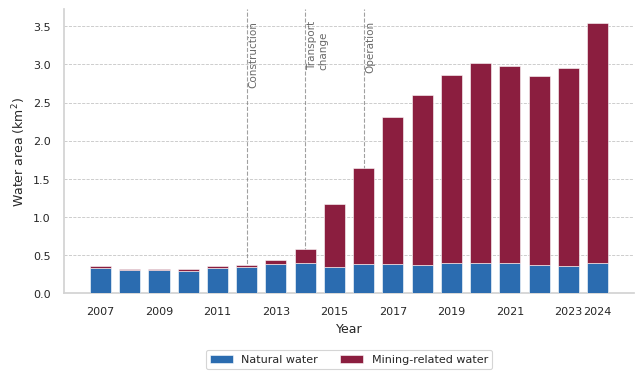

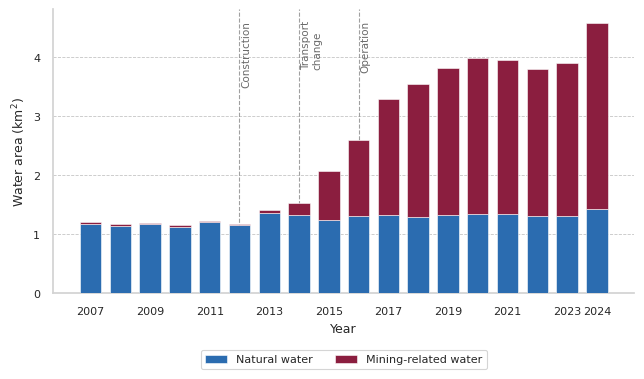

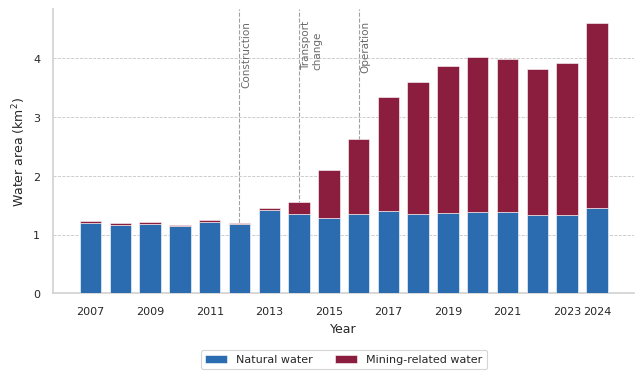

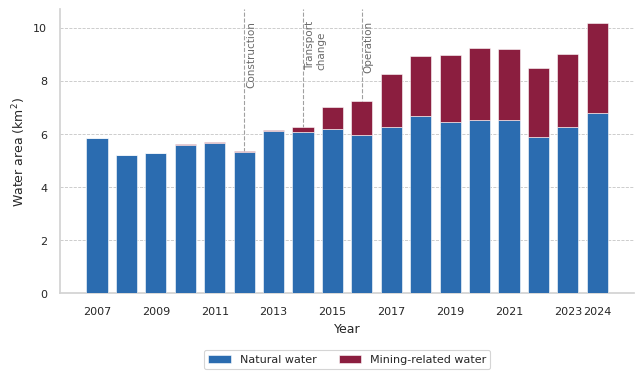

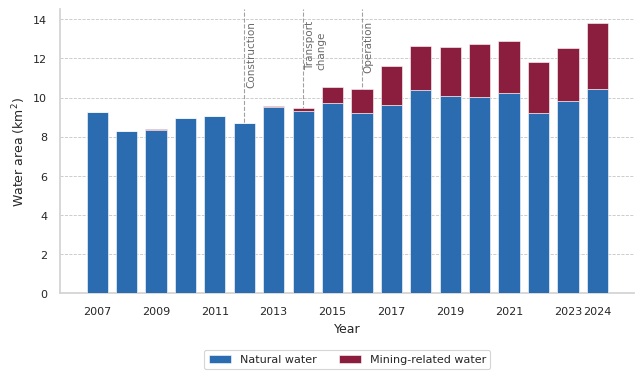

In [ ]:
plot_water_comparison_journal("Mapa_agua/mapbiomasagua2007_simplificado.pdf", df_2007, show=True)
plot_water_comparison_journal("Mapa_agua/mapbiomasagua2011_simplificado.pdf", df_2011, show=True)
plot_water_comparison_journal("Mapa_agua/mapbiomasagua2013_simplificado.pdf", df_2013, show=True)
plot_water_comparison_journal("Mapa_agua/mapbiomasagua2018_simplificado.pdf", df_2018, show=True)
plot_water_comparison_journal("Mapa_agua/mapbiomasagua2024_simplificado.pdf", df_2024, show=True)